In [1]:
import pandas as pd
import numpy as np
import pyarrow
import polars as pl

print("¡Todo funciona correctamente!")
print("Python/pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("PyArrow:", pyarrow.__version__)
print("Polars:", pl.__version__)

¡Todo funciona correctamente!
Python/pandas: 2.3.3
NumPy: 2.2.6
PyArrow: 25.0.1
Polars: 1.43.2


In [2]:
import pandas as pd
from pathlib import Path

# Ruta recomendada para reproducir el proyecto
RAW = Path("data/raw")

# Ruta alternativa utilizada en esta computadora
if not RAW.exists():
    RAW = Path(
        r"C:\Users\biolo\OneDrive\Documentos\proyecto_synthea\data\raw"
    )

if not RAW.exists():
    raise FileNotFoundError(
        "No se encontró data/raw. Descarga los archivos de Synthea "
        "y colócalos en esa carpeta."
    )

print("Datos utilizados desde:", RAW.resolve())

patients = pd.read_csv(RAW / "patients.csv")
encounters = pd.read_csv(RAW / "encounters.csv")
observations = pd.read_csv(RAW / "observations.csv")

print("Los tres archivos se cargaron correctamente.")

Datos utilizados desde: C:\Users\biolo\OneDrive\Documentos\proyecto_synthea\data\raw
Los tres archivos se cargaron correctamente.


In [3]:
print("Memoria de patients.csv:",
      patients.memory_usage(deep=True).sum() / 1024**2, "MB")

print("Memoria de encounters.csv:",
      encounters.memory_usage(deep=True).sum() / 1024**2, "MB")

print("Memoria de observations.csv:",
      observations.memory_usage(deep=True).sum() / 1024**2, "MB")

Memoria de patients.csv: 1.4328317642211914 MB
Memoria de encounters.csv: 50.33945369720459 MB
Memoria de observations.csv: 337.3633670806885 MB


In [4]:
print("PATIENTS")
print(patients.dtypes)

print("\nENCOUNTERS")
print(encounters.dtypes)

print("\nOBSERVATIONS")
print(observations.dtypes)

PATIENTS
Id                      object
BIRTHDATE               object
DEATHDATE               object
SSN                     object
DRIVERS                 object
PASSPORT                object
PREFIX                  object
FIRST                   object
LAST                    object
SUFFIX                  object
MAIDEN                  object
MARITAL                 object
RACE                    object
ETHNICITY               object
GENDER                  object
BIRTHPLACE              object
ADDRESS                 object
CITY                    object
STATE                   object
COUNTY                  object
ZIP                    float64
LAT                    float64
LON                    float64
HEALTHCARE_EXPENSES    float64
HEALTHCARE_COVERAGE    float64
dtype: object

ENCOUNTERS
Id                      object
START                   object
STOP                    object
PATIENT                 object
ORGANIZATION            object
PROVIDER                object
PAYE

### Clasificación de las columnas de patients.csv

- **Identificadores:** `Id`, `SSN`, `DRIVERS` y `PASSPORT`.
- **Fechas:** `BIRTHDATE` y `DEATHDATE`.
- **Categóricas:** `PREFIX`, `SUFFIX`, `MARITAL`, `RACE`, `ETHNICITY`, `GENDER`,
  `BIRTHPLACE`, `CITY`, `STATE`, `COUNTY` y `ZIP`.
- **Texto:** `FIRST`, `LAST`, `MAIDEN` y `ADDRESS`.
- **Numéricas:** `LAT`, `LON`, `HEALTHCARE_EXPENSES` y `HEALTHCARE_COVERAGE`.

`ZIP` se considera un código y no una cantidad numérica, porque no se utilizará para
hacer operaciones matemáticas. Las variables categóricas tienen valores que pueden
repetirse entre muchos pacientes.

In [5]:
patients_dtypes = pd.read_csv(
    RAW / "patients.csv",

    dtype={
        # Identificadores
        "Id": "string",
        "SSN": "string",
        "DRIVERS": "string",
        "PASSPORT": "string",

        # Categorías
        "PREFIX": "category",
        "SUFFIX": "category",
        "MARITAL": "category",
        "RACE": "category",
        "ETHNICITY": "category",
        "GENDER": "category",
        "BIRTHPLACE": "category",
        "CITY": "category",
        "STATE": "category",
        "COUNTY": "category",
        "ZIP": "string",

        # Texto
        "FIRST": "string",
        "LAST": "string",
        "MAIDEN": "string",
        "ADDRESS": "string",

        # Valores numéricos
        "LAT": "float64",
        "LON": "float64",
        "HEALTHCARE_EXPENSES": "float64",
        "HEALTHCARE_COVERAGE": "float64"
    },

    parse_dates=["BIRTHDATE", "DEATHDATE"]
)

print("patients.csv se cargó con dtypes explícitos.")
print(patients_dtypes.dtypes)

patients.csv se cargó con dtypes explícitos.
Id                     string[python]
BIRTHDATE              datetime64[ns]
DEATHDATE              datetime64[ns]
SSN                    string[python]
DRIVERS                string[python]
PASSPORT               string[python]
PREFIX                       category
FIRST                  string[python]
LAST                   string[python]
SUFFIX                       category
MAIDEN                 string[python]
MARITAL                      category
RACE                         category
ETHNICITY                    category
GENDER                       category
BIRTHPLACE                   category
ADDRESS                string[python]
CITY                         category
STATE                        category
COUNTY                       category
ZIP                    string[python]
LAT                           float64
LON                           float64
HEALTHCARE_EXPENSES           float64
HEALTHCARE_COVERAGE           float64
dtype

In [6]:
encounters_dtypes = pd.read_csv(
    RAW / "encounters.csv",

    dtype={
        # Identificadores
        "Id": "string",
        "PATIENT": "string",
        "ORGANIZATION": "string",
        "PROVIDER": "string",
        "PAYER": "string",

        # Categorías
        "ENCOUNTERCLASS": "category",
        "DESCRIPTION": "category",
        "REASONDESCRIPTION": "category",

        # Códigos
        "CODE": "string",
        "REASONCODE": "string",

        # Valores numéricos
        "BASE_ENCOUNTER_COST": "float64",
        "TOTAL_CLAIM_COST": "float64",
        "PAYER_COVERAGE": "float64"
    },

    parse_dates=["START", "STOP"]
)

print("encounters.csv se cargó con dtypes explícitos.")
print(encounters_dtypes.dtypes)

encounters.csv se cargó con dtypes explícitos.
Id                          string[python]
START                  datetime64[ns, UTC]
STOP                   datetime64[ns, UTC]
PATIENT                     string[python]
ORGANIZATION                string[python]
PROVIDER                    string[python]
PAYER                       string[python]
ENCOUNTERCLASS                    category
CODE                        string[python]
DESCRIPTION                       category
BASE_ENCOUNTER_COST                float64
TOTAL_CLAIM_COST                   float64
PAYER_COVERAGE                     float64
REASONCODE                  string[python]
REASONDESCRIPTION                 category
dtype: object


In [7]:
observations_dtypes = pd.read_csv(
    RAW / "observations.csv",

    dtype={
        # Identificadores
        "PATIENT": "string",
        "ENCOUNTER": "string",

        # Código clínico
        "CODE": "string",

        # Categorías
        "CATEGORY": "category",
        "DESCRIPTION": "category",
        "UNITS": "category",
        "TYPE": "category",

        # Mezcla resultados numéricos y de texto
        "VALUE": "string"
    },

    parse_dates=["DATE"]
)

print("observations.csv se cargó con dtypes explícitos.")
print(observations_dtypes.dtypes)

observations.csv se cargó con dtypes explícitos.
DATE           datetime64[ns, UTC]
PATIENT             string[python]
ENCOUNTER           string[python]
CATEGORY                  category
CODE                string[python]
DESCRIPTION               category
VALUE               string[python]
UNITS                     category
TYPE                      category
dtype: object


In [8]:
comparacion_memoria = pd.DataFrame({
    "Archivo": [
        "patients.csv",
        "encounters.csv",
        "observations.csv"
    ],

    "Memoria antes (MB)": [
        patients.memory_usage(deep=True).sum() / 1024**2,
        encounters.memory_usage(deep=True).sum() / 1024**2,
        observations.memory_usage(deep=True).sum() / 1024**2
    ],

    "Memoria después (MB)": [
        patients_dtypes.memory_usage(deep=True).sum() / 1024**2,
        encounters_dtypes.memory_usage(deep=True).sum() / 1024**2,
        observations_dtypes.memory_usage(deep=True).sum() / 1024**2
    ]
})

comparacion_memoria["Reducción (%)"] = (
    1
    - comparacion_memoria["Memoria después (MB)"]
    / comparacion_memoria["Memoria antes (MB)"]
) * 100

comparacion_memoria.round(2)

,Archivo,Memoria antes (MB),Memoria después (MB),Reducción (%)
0,patients.csv,1.43,0.81,43.20
1,encounters.csv,50.34,37.08,26.33
2,observations.csv,337.36,164.08,51.36


### Resultados de la carga con dtypes explícitos

La declaración explícita de los tipos de datos redujo el consumo de memoria en los tres archivos:

- `patients.csv` pasó de 1.43 MB a 0.81 MB, una reducción de 43.20%.
- `encounters.csv` pasó de 50.34 MB a 37.08 MB, una reducción de 26.33%.
- `observations.csv` pasó de 337.36 MB a 164.08 MB, una reducción de 51.36%.

La mayor reducción en términos absolutos se obtuvo en `observations.csv`, principalmente por convertir columnas repetitivas de tipo `object` a `category`. Las fechas también se convirtieron a `datetime` y los identificadores y códigos clínicos se conservaron como texto.

Estos resultados muestran que elegir los tipos de datos de manera explícita puede disminuir considerablemente el uso de memoria sin eliminar columnas ni registros.

## Actividad 2. Reducir la memoria al menos 70%

In [9]:
memoria_por_columna = pd.DataFrame({
    "dtype antes": observations.dtypes.astype(str),
    "MB antes": observations.memory_usage(deep=True) / 1024**2,
    "dtype actual": observations_dtypes.dtypes.astype(str),
    "MB actual": observations_dtypes.memory_usage(deep=True) / 1024**2
})

memoria_por_columna.sort_values(
    "MB antes",
    ascending=False
).round(2)

,dtype antes,MB antes,dtype actual,MB actual
DESCRIPTION,object,51.66,category,1.05
PATIENT,object,47.11,string,47.11
ENCOUNTER,object,45.27,string,45.99
DATE,object,39.00,"datetime64[ns, UTC]",4.05
VALUE,object,32.23,string,32.23
CATEGORY,object,32.16,category,0.51
CODE,object,32.14,string,32.14
TYPE,object,31.85,category,0.51
UNITS,object,25.96,category,0.51
Index,NaN,0.00,NaN,0.00


In [10]:
import pyarrow as pa

print("PyArrow está instalado.")
print("Versión:", pa.__version__)


PyArrow está instalado.
Versión: 25.0.1


In [11]:
observations_optimizado = observations_dtypes.copy()

# Identificadores y códigos que se repiten muchas veces
observations_optimizado["PATIENT"] = (
    observations_optimizado["PATIENT"].astype("category")
)

observations_optimizado["ENCOUNTER"] = (
    observations_optimizado["ENCOUNTER"].astype("category")
)

observations_optimizado["CODE"] = (
    observations_optimizado["CODE"].astype("category")
)

# Texto con almacenamiento eficiente de PyArrow
observations_optimizado["VALUE"] = (
    observations_optimizado["VALUE"].astype("string[pyarrow]")
)

memoria_original = observations.memory_usage(deep=True).sum() / 1024**2
memoria_optimizada = observations_optimizado.memory_usage(deep=True).sum() / 1024**2

reduccion = (
    1 - memoria_optimizada / memoria_original
) * 100

print("Memoria original:", round(memoria_original, 2), "MB")
print("Memoria optimizada:", round(memoria_optimizada, 2), "MB")
print("Reducción:", round(reduccion, 2), "%")

Memoria original: 337.36 MB
Memoria optimizada: 19.59 MB
Reducción: 94.19 %


In [12]:
consecuencias = {
    "DATE": "Se pierde la representación textual original; las fechas quedan normalizadas a UTC.",
    "PATIENT": "Agregar identificadores nuevos requiere añadirlos primero como categorías.",
    "ENCOUNTER": "Agregar identificadores nuevos requiere añadirlos primero como categorías.",
    "CATEGORY": "Las operaciones de texto y la incorporación de categorías nuevas son menos directas.",
    "CODE": "Las operaciones de texto y la incorporación de códigos nuevos son menos directas.",
    "DESCRIPTION": "Las operaciones de texto y la incorporación de descripciones nuevas son menos directas.",
    "VALUE": "Puede haber menor compatibilidad con algunas operaciones basadas en objetos de Python.",
    "UNITS": "La incorporación de unidades nuevas requiere ampliar las categorías.",
    "TYPE": "La incorporación de tipos nuevos requiere ampliar las categorías."
}

tabla_conversiones = pd.DataFrame({
    "Columna": observations.columns,
    "dtype antes": [
        str(observations[columna].dtype)
        for columna in observations.columns
    ],
    "dtype después": [
        str(observations_optimizado[columna].dtype)
        for columna in observations.columns
    ],
    "MB antes": [
        observations[columna].memory_usage(deep=True, index=False) / 1024**2
        for columna in observations.columns
    ],
    "MB después": [
        observations_optimizado[columna].memory_usage(
            deep=True,
            index=False
        ) / 1024**2
        for columna in observations.columns
    ],
    "Qué se pierde": [
        consecuencias[columna]
        for columna in observations.columns
    ]
})

tabla_conversiones.round(2)

,Columna,dtype antes,dtype después,MB antes,MB después,Qué se pierde
0,DATE,object,"datetime64[ns, UTC]",39.00,4.05,Se pierde la representación textual original; ...
1,PATIENT,object,category,47.11,1.15,Agregar identificadores nuevos requiere añadir...
2,ENCOUNTER,object,category,45.27,3.38,Agregar identificadores nuevos requiere añadir...
3,CATEGORY,object,category,32.16,0.51,Las operaciones de texto y la incorporación de...
4,CODE,object,category,32.14,1.04,Las operaciones de texto y la incorporación de...
5,DESCRIPTION,object,category,51.66,1.05,Las operaciones de texto y la incorporación de...
6,VALUE,object,string,32.23,7.41,Puede haber menor compatibilidad con algunas o...
7,UNITS,object,category,25.96,0.51,La incorporación de unidades nuevas requiere a...
8,TYPE,object,category,31.85,0.51,La incorporación de tipos nuevos requiere ampl...


In [13]:
from IPython.display import display

tabla_visible = (
    tabla_conversiones
    .round(2)
    .style
    .set_properties(
        subset=["Qué se pierde"],
        **{
            "white-space": "normal",
            "text-align": "left",
            "min-width": "350px"
        }
    )
    .set_properties(
        subset=["Columna", "dtype antes", "dtype después"],
        **{
            "white-space": "nowrap",
            "text-align": "left"
        }
    )
    .format({
        "MB antes": "{:.2f}",
        "MB después": "{:.2f}"
    })
)

display(tabla_visible)

,Columna,dtype antes,dtype después,MB antes,MB después,Qué se pierde
0,DATE,object,"datetime64[ns, UTC]",39.00,4.05,Se pierde la representación textual original; las fechas quedan normalizadas a UTC.
1,PATIENT,object,category,47.11,1.15,Agregar identificadores nuevos requiere añadirlos primero como categorías.
2,ENCOUNTER,object,category,45.27,3.38,Agregar identificadores nuevos requiere añadirlos primero como categorías.
3,CATEGORY,object,category,32.16,0.51,Las operaciones de texto y la incorporación de categorías nuevas son menos directas.
4,CODE,object,category,32.14,1.04,Las operaciones de texto y la incorporación de códigos nuevos son menos directas.
5,DESCRIPTION,object,category,51.66,1.05,Las operaciones de texto y la incorporación de descripciones nuevas son menos directas.
6,VALUE,object,string,32.23,7.41,Puede haber menor compatibilidad con algunas operaciones basadas en objetos de Python.
7,UNITS,object,category,25.96,0.51,La incorporación de unidades nuevas requiere ampliar las categorías.
8,TYPE,object,category,31.85,0.51,La incorporación de tipos nuevos requiere ampliar las categorías.


### Conclusión de la optimización de memoria

El DataFrame `observations.csv` consumía inicialmente **337.36 MB**. Después de declarar
y optimizar los tipos de datos, su consumo disminuyó a **19.59 MB**, lo que representa
una reducción de **94.19%**.

Por lo tanto, se superó el criterio mínimo de reducción del 70%.

La reducción se consiguió principalmente al convertir las columnas con valores repetidos,
como `PATIENT`, `ENCOUNTER`, `CATEGORY`, `CODE`, `DESCRIPTION`, `UNITS` y `TYPE`,
al tipo `category`. La columna `DATE` se convirtió de texto a fecha y `VALUE` se almacenó
como `string[pyarrow]`.

Estas conversiones conservan los valores del dataset, pero introducen algunas limitaciones.
Las columnas categóricas requieren ampliar previamente sus categorías para incorporar
valores nuevos, mientras que `string[pyarrow]` puede tener menor compatibilidad con
algunas operaciones diseñadas específicamente para objetos de Python.

## Actividad 3. Auditar la calidad de los datos

### Porcentaje de valores faltantes

In [14]:
faltantes_patients = (
    patients_dtypes.isna().mean().mul(100).round(2)
    .sort_values(ascending=False)
    .to_frame("Faltantes (%)")
)

faltantes_encounters = (
    encounters_dtypes.isna().mean().mul(100).round(2)
    .sort_values(ascending=False)
    .to_frame("Faltantes (%)")
)

faltantes_observations = (
    observations_optimizado.isna().mean().mul(100).round(2)
    .sort_values(ascending=False)
    .to_frame("Faltantes (%)")
)

print("PATIENTS")
display(faltantes_patients)

print("ENCOUNTERS")
display(faltantes_encounters)

print("OBSERVATIONS")
display(faltantes_observations)

PATIENTS


,Faltantes (%)
SUFFIX,98.62
DEATHDATE,85.98
MAIDEN,71.54
ZIP,46.86
MARITAL,33.02
PASSPORT,23.73
PREFIX,21.07
DRIVERS,18.49
Id,0.00
LAST,0.00


ENCOUNTERS


,Faltantes (%)
REASONCODE,74.04
REASONDESCRIPTION,74.04
Id,0.00
PATIENT,0.00
ORGANIZATION,0.00
START,0.00
STOP,0.00
PAYER,0.00
PROVIDER,0.00
ENCOUNTERCLASS,0.00


OBSERVATIONS


,Faltantes (%)
UNITS,34.83
CATEGORY,5.96
ENCOUNTER,5.96
DATE,0.00
PATIENT,0.00
CODE,0.00
DESCRIPTION,0.00
VALUE,0.00
TYPE,0.00


### Hallazgos sobre valores faltantes

En `patients.csv`, las columnas con más valores faltantes son `SUFFIX` (98.62%),
`DEATHDATE` (85.98%) y `MAIDEN` (71.54%). Estos valores faltantes no necesariamente
representan errores. La ausencia de `DEATHDATE` probablemente corresponde a pacientes
que permanecen vivos; `SUFFIX` sólo aplica a personas con un sufijo en su nombre y
`MAIDEN` no aplica a todos los pacientes.

También se encontraron valores faltantes en `ZIP` (46.86%), `MARITAL` (33.02%),
`PASSPORT` (23.73%), `PREFIX` (21.07%) y `DRIVERS` (18.49%). Algunos pueden deberse
a que esos datos no son aplicables para determinados pacientes, aunque el porcentaje
elevado de valores faltantes en `ZIP` requeriría revisión antes de realizar un análisis
geográfico.

En `encounters.csv`, `REASONCODE` y `REASONDESCRIPTION` presentan 74.04% de valores
faltantes. Esto indica que muchos encuentros no tienen registrado un motivo clínico
específico. Las demás columnas están completas.

En `observations.csv`, `UNITS` tiene 34.83% de valores faltantes. Esto puede ocurrir
cuando la observación contiene un resultado categórico y no una medición numérica.
`CATEGORY` y `ENCOUNTER` tienen 5.96% de valores faltantes. Será necesario revisar
esas filas para determinar qué tipos de observaciones no están asociados a un encuentro
o a una categoría.

Los valores faltantes no se eliminarán automáticamente, ya que primero debe determinarse
si representan un error, un dato desconocido o una característica que no aplica.

### Identificadores duplicados en patients.csv

In [15]:
cantidad_duplicados = patients_dtypes["Id"].duplicated().sum()

print("Número de pacientes:", len(patients_dtypes))
print("Identificadores Id duplicados:", cantidad_duplicados)

if cantidad_duplicados > 0:
    pacientes_duplicados = patients_dtypes[
        patients_dtypes["Id"].duplicated(keep=False)
    ].sort_values("Id")

    display(pacientes_duplicados)
else:
    print("Cada paciente tiene un identificador único.")

Número de pacientes: 1163
Identificadores Id duplicados: 0
Cada paciente tiene un identificador único.


### Hallazgo sobre identificadores duplicados

El archivo `patients.csv` contiene **1,163 pacientes** y no se encontraron valores
duplicados en la columna `Id`. Por lo tanto, cada fila representa a un paciente diferente
y el identificador puede utilizarse como llave única en las uniones posteriores.

### Coherencia temporal de los encuentros

In [16]:
encuentros_temporales = encounters_dtypes.merge(
    patients_dtypes[["Id", "BIRTHDATE", "DEATHDATE"]],
    left_on="PATIENT",
    right_on="Id",
    how="left",
    validate="many_to_one",
    suffixes=("_encounter", "_patient")
)

# Eliminar la zona horaria y conservar únicamente el día
fecha_encuentro = (
    encuentros_temporales["START"]
    .dt.tz_localize(None)
    .dt.normalize()
)

fecha_nacimiento = (
    encuentros_temporales["BIRTHDATE"]
    .dt.normalize()
)

fecha_defuncion = (
    encuentros_temporales["DEATHDATE"]
    .dt.normalize()
)

antes_del_nacimiento = encuentros_temporales[
    fecha_encuentro < fecha_nacimiento
]

despues_de_defuncion = encuentros_temporales[
    fecha_defuncion.notna()
    & (fecha_encuentro > fecha_defuncion)
]

print(
    "Encuentros anteriores al nacimiento:",
    len(antes_del_nacimiento)
)

print(
    "Encuentros posteriores a la defunción:",
    len(despues_de_defuncion)
)

Encuentros anteriores al nacimiento: 0
Encuentros posteriores a la defunción: 165


In [17]:
revision_post_defuncion = despues_de_defuncion.copy()

revision_post_defuncion["DIAS_DESPUES"] = (
    revision_post_defuncion["START"]
    .dt.tz_localize(None)
    .dt.normalize()
    - revision_post_defuncion["DEATHDATE"].dt.normalize()
).dt.days

print("Días transcurridos entre la defunción y el encuentro:")
display(
    revision_post_defuncion["DIAS_DESPUES"]
    .describe()
    .round(2)
)

print("\nTipos de encuentros posteriores a la defunción:")
display(
    revision_post_defuncion["ENCOUNTERCLASS"]
    .value_counts()
)

print("\nDescripciones más frecuentes:")
display(
    revision_post_defuncion["DESCRIPTION"]
    .value_counts()
    .head(10)
)

print("\nEjemplos:")
display(
    revision_post_defuncion[
        [
            "PATIENT",
            "DEATHDATE",
            "START",
            "ENCOUNTERCLASS",
            "DESCRIPTION",
            "DIAS_DESPUES"
        ]
    ].head(10)
)

Días transcurridos entre la defunción y el encuentro:


count    165.00
mean       5.75
std        3.21
min        1.00
25%        3.00
50%        7.00
75%        7.00
max       14.00
Name: DIAS_DESPUES, dtype: float64


Tipos de encuentros posteriores a la defunción:


ENCOUNTERCLASS
wellness      157
emergency       8
ambulatory      0
inpatient       0
outpatient      0
urgentcare      0
Name: count, dtype: int64


Descripciones más frecuentes:


DESCRIPTION
Death Certification                             154
Myocardial Infarction                             4
General examination of patient (procedure)        3
Emergency room admission (procedure)              2
Stroke                                            1
Cardiac Arrest                                    1
Admission to surgical department                  0
Asthma follow-up                                  0
Admission to intensive care unit (procedure)      0
Admission to thoracic surgery department          0
Name: count, dtype: int64


Ejemplos:


,PATIENT,DEATHDATE,START,ENCOUNTERCLASS,DESCRIPTION,DIAS_DESPUES
405,55a6a46e-a1a4-0298-e58f-c0cb27cbb022,2009-11-13,2009-11-19 04:22:51+00:00,wellness,Death Certification,6
1105,7024858b-f5e2-efee-8e2f-67f503fef6a5,1997-02-17,1997-02-22 04:45:24+00:00,wellness,Death Certification,5
2939,9ac43dbb-44d6-871e-b411-a1c18c61b55e,1996-05-12,1996-05-16 20:10:59+00:00,wellness,Death Certification,4
3291,10a1709a-5dde-1e3a-4c06-d8de03764712,2011-07-10,2011-07-11 06:09:28+00:00,wellness,Death Certification,1
3409,96df4283-1388-506c-e88f-77cd4232e1b4,1993-01-06,1993-01-07 20:10:59+00:00,wellness,Death Certification,1
3582,87cecc0c-9c64-cc50-5370-d7c881ccbd61,2008-06-21,2008-07-02 09:54:43+00:00,wellness,Death Certification,11
3694,33b3cedc-e045-2a40-e5b7-116ede5d8c66,2019-10-10,2019-10-16 20:03:35+00:00,wellness,Death Certification,6
4134,289f0cd9-e5d2-d575-b227-51874433bb33,1995-11-07,1995-11-11 16:48:47+00:00,wellness,Death Certification,4
5358,cbf4f991-0ef5-2f3f-122d-2b73edb21c1f,2021-07-07,2021-07-14 10:46:35+00:00,wellness,Death Certification,7
6571,ff0e4d0e-6181-e36e-d817-64dbcaecb5d0,2008-04-04,2008-04-11 12:43:40+00:00,wellness,Death Certification,7


### Hallazgos sobre coherencia temporal

No se encontraron encuentros anteriores a la fecha de nacimiento de los pacientes.

Se identificaron **165 encuentros registrados después de la fecha de defunción**. Estos
ocurrieron entre 1 y 14 días después, con una mediana de 7 días.

De los 165 registros, **154 corresponden a “Death Certification”**, por lo que probablemente
son procedimientos administrativos generados después del fallecimiento y no encuentros
clínicos reales. Estos registros no deben eliminarse automáticamente, pero deben
distinguirse de la atención clínica en análisis posteriores.

Los otros **11 encuentros** incluyen infarto de miocardio, examen general, admisión a
urgencias, evento vascular cerebral y paro cardiaco. Estos casos requieren una revisión
adicional porque podrían representar documentación tardía, eventos relacionados con el
fallecimiento o inconsistencias temporales del dataset sintético.

Por lo tanto, la comparación directa entre `START` y `DEATHDATE` puede señalar casos
sospechosos, pero el contexto y la descripción del encuentro son necesarios antes de
clasificarlos como errores.

### Valores numéricos y categóricos en observations.csv

In [18]:
value_numerico = pd.to_numeric(
    observations_optimizado["VALUE"],
    errors="coerce"
)

mascara_no_numericos = (
    value_numerico.isna()
    & observations_optimizado["VALUE"].notna()
)

cantidad_no_numericos = mascara_no_numericos.sum()

porcentaje_no_numericos = (
    mascara_no_numericos.mean() * 100
)

print("Total de observaciones:", len(observations_optimizado))
print("Valores que no se pueden convertir a número:", cantidad_no_numericos)
print(
    "Porcentaje no numérico:",
    round(porcentaje_no_numericos, 2),
    "%"
)

print("\nValores no numéricos más frecuentes:")
display(
    observations_optimizado.loc[
        mascara_no_numericos,
        "VALUE"
    ]
    .value_counts()
    .head(20)
)

print("\nEjemplos de las filas:")
display(
    observations_optimizado.loc[
        mascara_no_numericos,
        ["DESCRIPTION", "VALUE", "UNITS", "TYPE"]
    ].head(20)
)

Total de observaciones: 531144
Valores que no se pueden convertir a número: 191092
Porcentaje no numérico: 35.98 %

Valores no numéricos más frecuentes:


VALUE
No                                      63663
Yes                                     15008
Never smoker                             9474
I have housing                           8810
English                                  8171
White                                    7020
I choose not to answer this question     6517
Full-time work                           5766
Private insurance                        5554
More than high school                    4804
Not at all                               3705
3 to 5 times a week                      3586
5 or more times a week                   3578
Former smoker                            3136
High school diploma or GED               2572
Medicare                                 2471
A little bit                             2321
Somewhat                                 1643
Part-time or temporary work              1616
Less than high school degree             1464
Name: count, dtype: int64[pyarrow]


Ejemplos de las filas:


,DESCRIPTION,VALUE,UNITS,TYPE
20,Tobacco smoking status NHIS,Never smoker,NaN,text
30,Tobacco smoking status NHIS,Never smoker,NaN,text
40,Tobacco smoking status NHIS,Never smoker,NaN,text
50,Tobacco smoking status NHIS,Never smoker,NaN,text
60,Tobacco smoking status NHIS,Never smoker,NaN,text
70,Tobacco smoking status NHIS,Never smoker,NaN,text
95,Tobacco smoking status NHIS,Never smoker,NaN,text
105,Tobacco smoking status NHIS,Never smoker,NaN,text
115,Tobacco smoking status NHIS,Never smoker,NaN,text
127,Tobacco smoking status NHIS,Never smoker,NaN,text


### Hallazgos sobre la columna VALUE

De las **531,144 observaciones**, se encontraron **191,092 valores que no pueden
convertirse a número**, equivalentes al **35.98%** del total. Por lo tanto, aproximadamente
el 64.02% de los valores sí tiene una representación numérica.

Los valores no numéricos más frecuentes incluyen respuestas como `No`, `Yes`,
`Never smoker`, `I have housing`, `English`, tipos de empleo, escolaridad y tipos de
seguro médico.

La revisión de las filas muestra que estos valores corresponden a observaciones de tipo
`text`, como el estado de consumo de tabaco. Por lo tanto, no representan errores ni
datos faltantes, sino resultados categóricos válidos.

Esto confirma que `VALUE` no debe convertirse completamente a un dtype numérico.
Para los análisis de mediciones clínicas será necesario crear una versión numérica con
`pd.to_numeric(errors="coerce")`, conservando también la columna original para no perder
las respuestas categóricas. La ausencia de `UNITS` en estas filas también es coherente,
pues respuestas como “Never smoker” no necesitan una unidad de medición.

## Actividad 4. Unir las tres tablas validando cardinalidades

### Primera unión: observations → encounters

Cada observación puede estar relacionada con un solo encuentro, mientras que un
encuentro puede tener muchas observaciones. Por lo tanto, la cardinalidad esperada es
**muchos a uno (`many_to_one`)**.

La unión se realizará conservando todas las observaciones mediante un `left merge`.
Antes de la unión existen 531,144 observaciones, por lo que el resultado también debe
contener 531,144 filas. Las observaciones que no tengan un identificador de encuentro
permanecerán en el resultado, pero serán identificadas como no unidas.

In [19]:
# Seleccionamos y renombramos las columnas necesarias de encounters
encounters_para_union = encounters_dtypes[
    [
        "Id",
        "PATIENT",
        "START",
        "STOP",
        "ENCOUNTERCLASS",
        "CODE",
        "DESCRIPTION"
    ]
].rename(
    columns={
        "Id": "ENCOUNTER_ID",
        "PATIENT": "PATIENT_ENCOUNTER",
        "CODE": "ENCOUNTER_CODE",
        "DESCRIPTION": "ENCOUNTER_DESCRIPTION"
    }
)

filas_antes = len(observations_optimizado)

observations_encounters = observations_optimizado.merge(
    encounters_para_union,
    left_on="ENCOUNTER",
    right_on="ENCOUNTER_ID",
    how="left",
    validate="many_to_one",
    indicator="union_encounter"
)

filas_despues = len(observations_encounters)

print("Filas antes de la unión:", filas_antes)
print("Filas después de la unión:", filas_despues)

print("\nResultado de la unión:")
display(
    observations_encounters["union_encounter"]
    .value_counts(dropna=False)
)

Filas antes de la unión: 531144
Filas después de la unión: 531144

Resultado de la unión:


union_encounter
both          499482
left_only      31662
right_only         0
Name: count, dtype: int64

In [20]:
observaciones_no_unidas = observations_encounters[
    observations_encounters["union_encounter"] == "left_only"
]

sin_identificador = (
    observaciones_no_unidas["ENCOUNTER"].isna().sum()
)

con_identificador_no_encontrado = (
    observaciones_no_unidas["ENCOUNTER"].notna().sum()
)

print("No unidas porque ENCOUNTER está vacío:", sin_identificador)
print(
    "No unidas aunque tenían identificador:",
    con_identificador_no_encontrado
)

print(
    "Porcentaje de observaciones no unidas:",
    round(len(observaciones_no_unidas) / len(observations_encounters) * 100, 2),
    "%"
)

No unidas porque ENCOUNTER está vacío: 31662
No unidas aunque tenían identificador: 0
Porcentaje de observaciones no unidas: 5.96 %


### Resultado de la unión observations → encounters

La unión conservó las **531,144 filas** de `observations.csv`, por lo que no se
multiplicaron ni eliminaron observaciones.

Se unieron correctamente **499,482 observaciones**. Las **31,662 observaciones restantes**
(5.96%) fueron clasificadas como `left_only`. Todas tenían un valor faltante en
`ENCOUNTER`; no se encontraron identificadores de encuentro presentes en observations
pero ausentes en encounters.

Por lo tanto, los registros no unidos no son producto de identificadores incorrectos,
sino de observaciones que originalmente no estaban asociadas a un encuentro.

### Segunda unión: observations-encounters → patients

Cada observación corresponde a un solo paciente, mientras que un paciente puede tener
muchas observaciones. Por lo tanto, la cardinalidad esperada es **muchos a uno
(`many_to_one`)**.

La unión se realizará conservando todas las observaciones mediante un `left merge`.
El resultado debe mantener las **531,144 filas** obtenidas en la primera unión.

In [21]:
patients_para_union = patients_dtypes[
    [
        "Id",
        "BIRTHDATE",
        "DEATHDATE",
        "GENDER",
        "RACE",
        "ETHNICITY",
        "CITY",
        "STATE"
    ]
].rename(
    columns={
        "Id": "PATIENT_ID"
    }
)

filas_antes_patients = len(observations_encounters)

dataset_unido = observations_encounters.merge(
    patients_para_union,
    left_on="PATIENT",
    right_on="PATIENT_ID",
    how="left",
    validate="many_to_one",
    indicator="union_patient"
)

filas_despues_patients = len(dataset_unido)

print(
    "Filas antes de unir con patients:",
    filas_antes_patients
)

print(
    "Filas después de unir con patients:",
    filas_despues_patients
)

print("\nResultado de la unión:")
display(
    dataset_unido["union_patient"]
    .value_counts(dropna=False)
)

Filas antes de unir con patients: 531144
Filas después de unir con patients: 531144

Resultado de la unión:


union_patient
both          531144
left_only          0
right_only         0
Name: count, dtype: int64

### Resultado de la unión con patients

Antes de la segunda unión había **531,144 filas** y después de la unión se conservaron
las mismas **531,144 filas**. Esto confirma que la operación no eliminó ni multiplicó
observaciones.

Las **531,144 observaciones** fueron clasificadas como `both`, lo que significa que todos
los identificadores de la columna `PATIENT` encontraron una coincidencia en
`patients.csv`. No se encontraron observaciones con identificadores de pacientes
inexistentes.

Las dos uniones cumplieron la cardinalidad esperada `many_to_one`, comprobada mediante
el parámetro `validate`. El parámetro `indicator` permitió identificar las observaciones
sin encuentro y confirmar que todos los pacientes sí estaban registrados.

El DataFrame final unido se almacenó con el nombre `dataset_unido`.

## Actividad 5. Responder preguntas clínicas

### Pacientes por grupo étnico y sexo

In [22]:
print("Valores de RACE:")
display(
    patients_dtypes["RACE"]
    .value_counts(dropna=False)
)

print("\nValores de ETHNICITY:")
display(
    patients_dtypes["ETHNICITY"]
    .value_counts(dropna=False)
)

print("\nValores de GENDER:")
display(
    patients_dtypes["GENDER"]
    .value_counts(dropna=False)
)

Valores de RACE:


RACE
white       963
black        96
asian        73
hawaiian     18
other        11
native        2
Name: count, dtype: int64


Valores de ETHNICITY:


ETHNICITY
nonhispanic    1058
hispanic        105
Name: count, dtype: int64


Valores de GENDER:


GENDER
F    616
M    547
Name: count, dtype: int64

#### Definición de los grupos

Se considerará como grupo `Hispanic` a cualquier paciente cuya variable `ETHNICITY`
sea `hispanic`, independientemente de su valor en `RACE`.

Los pacientes `nonhispanic` se dividirán en `Non-Hispanic White`,
`Non-Hispanic Black`, `Non-Hispanic Asian` y `Non-Hispanic Other`.

Las categorías `hawaiian`, `native` y `other` se agruparán como
`Non-Hispanic Other` porque contienen pocos pacientes por separado. Esta agrupación
facilita la comparación y evita presentar resultados basados en grupos demasiado pequeños.

Para sexo se conservarán las categorías originales `F` y `M`.

In [23]:
import numpy as np

pacientes_grupos = patients_dtypes.copy()

raza = pacientes_grupos["RACE"].astype("string")
etnicidad = pacientes_grupos["ETHNICITY"].astype("string")

condiciones = [
    etnicidad.eq("hispanic"),
    etnicidad.eq("nonhispanic") & raza.eq("white"),
    etnicidad.eq("nonhispanic") & raza.eq("black"),
    etnicidad.eq("nonhispanic") & raza.eq("asian")
]

nombres_grupos = [
    "Hispanic",
    "Non-Hispanic White",
    "Non-Hispanic Black",
    "Non-Hispanic Asian"
]

pacientes_grupos["GRUPO_ETNICO"] = np.select(
    condiciones,
    nombres_grupos,
    default="Non-Hispanic Other"
)

pacientes_por_grupo_sexo = pd.crosstab(
    pacientes_grupos["GRUPO_ETNICO"],
    pacientes_grupos["GENDER"],
    margins=True,
    margins_name="Total"
)

display(pacientes_por_grupo_sexo)

GENDER,F,M,Total
GRUPO_ETNICO,,,
Hispanic,59,46,105
Non-Hispanic Asian,31,38,69
Non-Hispanic Black,28,54,82
Non-Hispanic Other,18,10,28
Non-Hispanic White,480,399,879
Total,616,547,1163


#### Hallazgos por grupo étnico y sexo

El dataset contiene **1,163 pacientes**: 616 clasificados como `F` y 547 como `M`.

El grupo más numeroso es `Non-Hispanic White`, con 879 pacientes, seguido de
`Hispanic` con 105, `Non-Hispanic Black` con 82, `Non-Hispanic Asian` con 69 y
`Non-Hispanic Other` con 28.

La distribución de pacientes no es equilibrada entre los grupos. Aproximadamente
tres cuartas partes pertenecen al grupo `Non-Hispanic White`, mientras que
`Non-Hispanic Other` contiene pocos pacientes. Por esta razón, las comparaciones
clínicas posteriores entre grupos deben interpretarse con precaución.

Estos conteos describen la composición del dataset sintético y no deben interpretarse
como una representación de la población general.

### Número medio y mediano de encuentros por paciente

In [24]:
encuentros_por_paciente = (
    encounters_dtypes["PATIENT"]
    .value_counts()
    .reindex(
        patients_dtypes["Id"],
        fill_value=0
    )
)

media_encuentros = encuentros_por_paciente.mean()
mediana_encuentros = encuentros_por_paciente.median()

print(
    "Número medio de encuentros por paciente:",
    round(media_encuentros, 2)
)

print(
    "Número mediano de encuentros por paciente:",
    round(mediana_encuentros, 2)
)

print(
    "Número mínimo de encuentros:",
    encuentros_por_paciente.min()
)

print(
    "Número máximo de encuentros:",
    encuentros_por_paciente.max()
)

Número medio de encuentros por paciente: 52.85
Número mediano de encuentros por paciente: 40.0
Número mínimo de encuentros: 2
Número máximo de encuentros: 1563


In [25]:
display(
    encuentros_por_paciente
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
)

count    1163.0
mean      52.85
std       72.63
min         2.0
25%        21.0
50%        40.0
75%        64.0
90%        92.0
95%       119.9
99%       307.8
max      1563.0
Name: count, dtype: Float64

#### Hallazgos sobre encuentros por paciente

Los 1,163 pacientes tienen una media de **52.85 encuentros** y una mediana de
**40 encuentros**. El número de encuentros varía entre 2 y 1,563 por paciente.

La media es mayor que la mediana porque la distribución está sesgada hacia la derecha:
algunos pacientes tienen una cantidad extraordinariamente alta de encuentros. El 75%
de los pacientes tiene hasta 64 encuentros y el 95% tiene aproximadamente 120 o menos,
pero el máximo alcanza 1,563.

Por esta razón, la mediana de 40 encuentros describe mejor a un paciente típico, mientras
que la media de 52.85 está influida por los pacientes con valores extremos.

El cálculo se realizó contando primero los encuentros de cada paciente y después
calculando la media y la mediana de esos conteos. No se utilizó una media de medias.
Además, se incluyeron todos los pacientes registrados, aunque en este dataset ninguno
tenía cero encuentros.

### Diez códigos de observación más frecuentes

In [26]:
codigos_frecuentes = (
    observations_optimizado
    .groupby(
        ["CODE", "DESCRIPTION"],
        observed=True
    )
    .size()
    .reset_index(name="Frecuencia")
    .sort_values(
        "Frecuencia",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

codigos_frecuentes.index = codigos_frecuentes.index + 1

display(codigos_frecuentes)

,CODE,DESCRIPTION,Frecuencia
1,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,14537
2,8480-6,Systolic Blood Pressure,14467
3,8462-4,Diastolic Blood Pressure,14467
4,29463-7,Body Weight,13275
5,8867-4,Heart rate,13014
6,9279-1,Respiratory rate,13014
7,8302-2,Body Height,12699
8,72166-2,Tobacco smoking status NHIS,12666
9,39156-5,Body Mass Index,11571
10,QOLS,QOLS,10554


#### Hallazgos sobre los códigos más frecuentes

La observación más frecuente es la evaluación de la intensidad del dolor, con
**14,537 registros**.

La presión arterial sistólica y la presión arterial diastólica tienen exactamente
**14,467 registros cada una**, lo cual sugiere que ambas mediciones generalmente se
registran juntas durante el mismo procedimiento clínico.

Entre las observaciones más frecuentes también se encuentran el peso corporal,
la frecuencia cardiaca, la frecuencia respiratoria, la estatura y el índice de masa
corporal. Esto muestra que una parte importante del dataset corresponde a signos vitales
y mediciones antropométricas rutinarias.

También aparecen observaciones categóricas, como el estado de consumo de tabaco,
y mediciones de calidad de vida como `QOLS`. Por tanto, `observations.csv` combina
mediciones numéricas con respuestas categóricas y escalas clínicas.

In [27]:
pd.set_option("display.max_colwidth", None)
display(codigos_frecuentes)

,CODE,DESCRIPTION,Frecuencia
1,72514-3,Pain severity - 0-10 verbal numeric rating [Score] - Reported,14537
2,8480-6,Systolic Blood Pressure,14467
3,8462-4,Diastolic Blood Pressure,14467
4,29463-7,Body Weight,13275
5,8867-4,Heart rate,13014
6,9279-1,Respiratory rate,13014
7,8302-2,Body Height,12699
8,72166-2,Tobacco smoking status NHIS,12666
9,39156-5,Body Mass Index,11571
10,QOLS,QOLS,10554


### Distribución de la presión arterial sistólica

Se eligió la presión arterial sistólica porque es una medición clínica cuantitativa,
aparece entre las observaciones más frecuentes y permite evaluar el seguimiento
longitudinal de los pacientes. Se utilizará el código `8480-6` para identificarla,
en lugar de depender únicamente de su descripción.

Total de mediciones sistólicas: 14467
Mediciones numéricas válidas: 14467
Pacientes con al menos una medición: 1158
Pacientes con al menos tres mediciones: 1155

Resumen de la distribución:


count    14467.00
mean       123.76
std         15.55
min         42.50
25%        113.00
50%        121.00
75%        130.00
max        202.00
Name: VALUE_NUM, dtype: float64

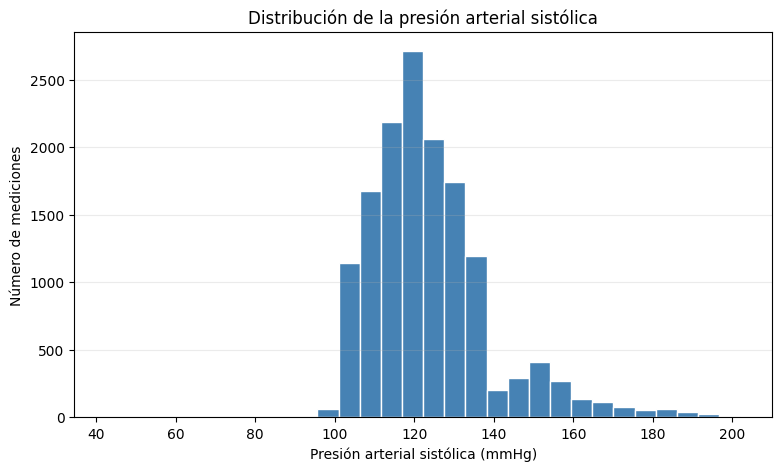

In [28]:
import matplotlib.pyplot as plt

sistolica = observations_optimizado.loc[
    observations_optimizado["CODE"].astype("string").eq("8480-6"),
    ["PATIENT", "DATE", "VALUE", "UNITS"]
].copy()

sistolica["VALUE_NUM"] = pd.to_numeric(
    sistolica["VALUE"],
    errors="coerce"
)

sistolica_validas = sistolica.dropna(
    subset=["VALUE_NUM"]
).copy()

# Convertir a float para los cálculos y la gráfica
sistolica_validas["VALUE_NUM"] = (
    sistolica_validas["VALUE_NUM"].astype("float64")
)

mediciones_por_paciente = (
    sistolica_validas.groupby(
        "PATIENT",
        observed=True
    )
    .size()
)

pacientes_tres_mediciones = (
    mediciones_por_paciente >= 3
).sum()

print("Total de mediciones sistólicas:", len(sistolica))
print("Mediciones numéricas válidas:", len(sistolica_validas))
print(
    "Pacientes con al menos una medición:",
    mediciones_por_paciente.size
)
print(
    "Pacientes con al menos tres mediciones:",
    pacientes_tres_mediciones
)

print("\nResumen de la distribución:")
display(
    sistolica_validas["VALUE_NUM"]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .round(2)
)

plt.figure(figsize=(9, 5))

plt.hist(
    sistolica_validas["VALUE_NUM"],
    bins=30,
    color="steelblue",
    edgecolor="white"
)

plt.title("Distribución de la presión arterial sistólica")
plt.xlabel("Presión arterial sistólica (mmHg)")
plt.ylabel("Número de mediciones")
plt.grid(axis="y", alpha=0.25)
plt.show()

#### Hallazgos sobre la presión arterial sistólica

Se encontraron **14,467 mediciones de presión arterial sistólica** y todas pudieron
convertirse correctamente a valores numéricos.

La media global fue de **123.76 mmHg** y la mediana de **121 mmHg**. El 50% central
de las mediciones se encontró entre 113 y 130 mmHg. Los valores variaron desde
42.50 hasta 202 mmHg, lo que indica la presencia de algunos valores extremos que
se revisarán posteriormente utilizando rangos fisiológicos respaldados por referencias.

De los 1,163 pacientes del dataset, **1,158 tuvieron al menos una medición** de presión
sistólica y **1,155 tuvieron al menos tres mediciones**. Por lo tanto, la mayoría cuenta
con suficientes mediciones para realizar un análisis longitudinal.

La media de 123.76 mmHg corresponde a todas las mediciones tomadas en conjunto.
No se calculó una media de las medias individuales de cada paciente, porque el objetivo
en esta sección es describir la distribución global de las observaciones. Esto implica
que los pacientes con más mediciones tienen mayor peso en el resultado global.

## Actividad 6. Formato ancho y valores implausibles

### Revisión de mediciones repetidas

Antes de transformar los datos, se comprobará si existen varias mediciones del mismo
analito para un paciente en una misma fecha. Si existen duplicados, se deberá elegir y
justificar una función de agregación, ya que `pivot_table` los combinaría automáticamente.

In [29]:
observaciones_numericas = observations_optimizado.copy()

observaciones_numericas["VALUE_NUM"] = pd.to_numeric(
    observaciones_numericas["VALUE"],
    errors="coerce"
)

# Conservar solamente observaciones numéricas
observaciones_numericas = observaciones_numericas.dropna(
    subset=["VALUE_NUM"]
).copy()

# Convertir fecha y hora a día
observaciones_numericas["FECHA"] = (
    observaciones_numericas["DATE"].dt.floor("D")
)

repeticiones = (
    observaciones_numericas
    .groupby(
        ["PATIENT", "FECHA", "CODE"],
        observed=True
    )
    .size()
)

grupos_repetidos = repeticiones[repeticiones > 1]

print(
    "Observaciones numéricas:",
    len(observaciones_numericas)
)

print(
    "Grupos paciente-fecha-código con más de una medición:",
    len(grupos_repetidos)
)

print(
    "Máximo de mediciones del mismo código en un día:",
    repeticiones.max()
)

display(
    grupos_repetidos
    .sort_values(ascending=False)
    .head(10)
    .to_frame("Número de mediciones")
)

Observaciones numéricas: 340052
Grupos paciente-fecha-código con más de una medición: 2984
Máximo de mediciones del mismo código en un día: 4


,,,Número de mediciones
PATIENT,FECHA,CODE,
78da7c78-d491-32b2-7ea2-aebb2517d27e,2021-01-09 00:00:00+00:00,2708-6,4
a7b1578d-868c-9f64-e678-0f218c65d3e8,2021-01-06 00:00:00+00:00,2708-6,4
78da7c78-d491-32b2-7ea2-aebb2517d27e,2020-12-31 00:00:00+00:00,2708-6,3
20a75f26-b297-4120-72e6-602ee5e9f4e4,2020-05-12 00:00:00+00:00,8310-5,3
050358a1-fcf7-1182-7ad1-6b663afa3002,2021-08-11 00:00:00+00:00,2708-6,3
236bc48b-5230-46f9-3725-a7b5274f4798,2021-04-07 00:00:00+00:00,2708-6,3
6fc7b50b-61ff-9237-bcac-7b7b1d8606ab,2021-04-19 00:00:00+00:00,8310-5,3
0142b69f-57f0-9a08-4e2d-65a2b77fdea7,1989-01-20 00:00:00+00:00,2339-0,2
f9e8b3e4-1c3f-c662-a310-516d338ee41a,2007-10-23 00:00:00+00:00,6299-2,2


In [30]:
observaciones_numericas["VALUE_NUM"] = (
    observaciones_numericas["VALUE_NUM"].astype("float64")
)

formato_ancho = (
    observaciones_numericas
    .pivot_table(
        index=["PATIENT", "FECHA"],
        columns="CODE",
        values="VALUE_NUM",
        aggfunc="median",
        observed=True
    )
    .reset_index()
)

formato_ancho.columns.name = None

print("Filas del formato ancho:", formato_ancho.shape[0])
print("Columnas del formato ancho:", formato_ancho.shape[1])

display(formato_ancho.head())

Filas del formato ancho: 31971
Columnas del formato ancho: 165


,PATIENT,FECHA,10230-1,10834-0,14804-9,14959-1,1742-6,1751-7,17861-6,18262-6,...,99999-3,99999-4,99999-5,99999-6,99999-7,99999-8,99999-9,DALY,QALY,QOLS
0,00126cb9-8460-4747-e302-c3609684531e,2011-05-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,23.0,1.0
1,00126cb9-8460-4747-e302-c3609684531e,2012-05-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,24.0,1.0
2,00126cb9-8460-4747-e302-c3609684531e,2012-09-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00126cb9-8460-4747-e302-c3609684531e,2012-09-02 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00126cb9-8460-4747-e302-c3609684531e,2013-05-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,25.0,1.0


### Detección de valores sistólicos implausibles

Para el control de calidad se utilizará un rango operativo de **60 a 250 mmHg**.
Zhao et al. emplearon estos límites al depurar mediciones de presión arterial en
MIMIC-IV, considerando implausibles los valores sistólicos menores de 60 o mayores
de 250 mmHg.

Este rango no representa normalidad clínica. La American Heart Association considera
que una presión sistólica superior a 180 mmHg puede ser grave, pero clínicamente real.
Por tanto, los valores extremos se marcarán para revisión y no se eliminarán
automáticamente.

Referencias:

- Zhao J. et al. (2025). https://pubmed.ncbi.nlm.nih.gov/41120869/
- American Heart Association. https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings

In [31]:
codigo_sistolica = "8480-6"

sistolica_ancha = formato_ancho[
    ["PATIENT", "FECHA", codigo_sistolica]
].dropna().copy()

sistolica_ancha = sistolica_ancha.rename(
    columns={codigo_sistolica: "SISTOLICA"}
)

limite_inferior = 60
limite_superior = 250

mascara_implausible = (
    (sistolica_ancha["SISTOLICA"] < limite_inferior)
    | (sistolica_ancha["SISTOLICA"] > limite_superior)
)

sistolica_implausible = sistolica_ancha[
    mascara_implausible
].copy()

sistolica_implausible["MOTIVO"] = np.where(
    sistolica_implausible["SISTOLICA"] < limite_inferior,
    "Menor de 60 mmHg",
    "Mayor de 250 mmHg"
)

print(
    "Mediciones sistólicas diarias:",
    len(sistolica_ancha)
)

print(
    "Valores menores de 60 mmHg:",
    (sistolica_ancha["SISTOLICA"] < 60).sum()
)

print(
    "Valores mayores de 250 mmHg:",
    (sistolica_ancha["SISTOLICA"] > 250).sum()
)

print(
    "Total marcado como implausible:",
    len(sistolica_implausible)
)

print(
    "Porcentaje marcado:",
    round(
        len(sistolica_implausible)
        / len(sistolica_ancha) * 100,
        2
    ),
    "%"
)

display(sistolica_implausible)

Mediciones sistólicas diarias: 14443
Valores menores de 60 mmHg: 3
Valores mayores de 250 mmHg: 0
Total marcado como implausible: 3
Porcentaje marcado: 0.02 %


,PATIENT,FECHA,SISTOLICA,MOTIVO
473,03bb882e-730f-0d96-cd3d-3caee932fef6,2014-08-15 00:00:00+00:00,42.5,Menor de 60 mmHg
568,04f25f73-04b2-469c-3806-540417a0d61c,2005-11-07 00:00:00+00:00,54.4,Menor de 60 mmHg
8340,4602928a-c165-443d-8d76-54ef0162f24f,2006-11-14 00:00:00+00:00,55.5,Menor de 60 mmHg


### Resultados y tratamiento de valores implausibles

El formato ancho contiene **31,971 filas** y **165 columnas**. Cada fila representa una
combinación paciente-fecha y cada columna adicional representa un código de observación.

Después de agregar con la mediana las mediciones repetidas, quedaron **14,443 mediciones
sistólicas diarias**. Esta cantidad es ligeramente menor que las 14,467 mediciones
originales porque algunas mediciones del mismo paciente ocurrieron el mismo día y se
resumieron en un solo valor.

Aplicando el rango operativo de 60 a 250 mmHg, se marcaron **3 valores menores de
60 mmHg**: 42.5, 54.4 y 55.5 mmHg. No se encontraron valores superiores a 250 mmHg.
Los tres valores representan aproximadamente **0.02%** de las mediciones sistólicas
diarias.

Estos registros se consideran sospechosos según el criterio de control de calidad, pero no
se eliminarán automáticamente. Primero se deberían verificar sus unidades, compararlos
con la presión diastólica y otras mediciones del mismo encuentro, revisar si hubo una
medición repetida y analizar el contexto clínico.

Si no fuera posible confirmar su validez, se conservarían en los datos originales, se
marcarían mediante una variable de calidad y podrían excluirse únicamente del análisis
principal. También se podría realizar un análisis de sensibilidad con y sin estos valores.
No se recomienda reemplazarlos por la media ni imputarlos sin evidencia.

Referencias:

- Zhao J. et al. (2025). https://pubmed.ncbi.nlm.nih.gov/41120869/
- American Heart Association. https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings

## Actividad 7. Procesar por lotes lo que no cabe

Se establece un presupuesto máximo de **200 MB** para procesar `observations.csv`.

El archivo se leerá en bloques de 50,000 filas utilizando `chunksize`. De cada bloque
solamente se cargarán `CODE` y `VALUE`, porque son las columnas necesarias para calcular
el conteo y la media de los valores numéricos por código.

Los resultados parciales se acumularán mediante sumas y conteos. No se conservarán todos
los bloques en memoria. El uso máximo de memoria durante el procesamiento se medirá con
`tracemalloc`.

In [32]:
import gc
import time
import tracemalloc

presupuesto_mb = 200
tamano_lote = 50_000

sumas_acumuladas = pd.Series(dtype="float64")
conteos_acumulados = pd.Series(dtype="float64")

filas_procesadas = 0
numero_lotes = 0

inicio = time.perf_counter()
tracemalloc.start()

for lote in pd.read_csv(
    RAW / "observations.csv",
    usecols=["CODE", "VALUE"],
    dtype={
        "CODE": "string[pyarrow]",
        "VALUE": "string[pyarrow]"
    },
    chunksize=tamano_lote
):
    numero_lotes += 1
    filas_procesadas += len(lote)

    lote["VALUE_NUM"] = pd.to_numeric(
        lote["VALUE"],
        errors="coerce"
    )

    resumen_lote = (
        lote.dropna(subset=["VALUE_NUM"])
        .groupby("CODE", observed=True)["VALUE_NUM"]
        .agg(["sum", "count"])
    )

    sumas_acumuladas = sumas_acumuladas.add(
        resumen_lote["sum"],
        fill_value=0
    )

    conteos_acumulados = conteos_acumulados.add(
        resumen_lote["count"],
        fill_value=0
    )

    del lote
    del resumen_lote
    gc.collect()

memoria_actual, memoria_pico = tracemalloc.get_traced_memory()
tracemalloc.stop()

tiempo_total = time.perf_counter() - inicio

resultado_lotes = pd.DataFrame({
    "SUMA": sumas_acumuladas,
    "CONTEO": conteos_acumulados
})

resultado_lotes["CONTEO"] = (
    resultado_lotes["CONTEO"].astype("int64")
)

resultado_lotes["MEDIA"] = (
    resultado_lotes["SUMA"]
    / resultado_lotes["CONTEO"]
)

memoria_pico_mb = memoria_pico / 1024**2

print("Filas procesadas:", filas_procesadas)
print("Número de lotes:", numero_lotes)
print("Tamaño de cada lote:", tamano_lote)
print("Tiempo total:", round(tiempo_total, 2), "segundos")
print("Memoria pico medida:", round(memoria_pico_mb, 2), "MB")
print("Presupuesto:", presupuesto_mb, "MB")
print("¿Se respetó el presupuesto?:", memoria_pico_mb < presupuesto_mb)

display(
    resultado_lotes
    .sort_values("CONTEO", ascending=False)
    .head(10)
    .round(2)
)

Filas procesadas: 531144
Número de lotes: 11
Tamaño de cada lote: 50000
Tiempo total: 5.15 segundos
Memoria pico medida: 5.9 MB
Presupuesto: 200 MB
¿Se respetó el presupuesto?: True


,SUMA,CONTEO,MEDIA
CODE,,,
72514-3,34649.0,14537,2.38
8480-6,1790456.2,14467,123.76
8462-4,1190919.0,14467,82.32
29463-7,886765.8,13275,66.8
8867-4,1055702.7,13014,81.12
9279-1,186248.0,13014,14.31
8302-2,1955459.5,12699,153.99
39156-5,301630.9,11571,26.07
QOLS,9515.8,10554,0.9


### Resultados del procesamiento por lotes

Se procesaron las **531,144 filas** completas de `observations.csv` en **11 lotes**,
con un tamaño máximo de 50,000 filas por lote.

El procesamiento tardó **7.08 segundos** y el pico de memoria medido con `tracemalloc`
fue de **5.90 MB**, muy por debajo del presupuesto establecido de 200 MB. Por tanto,
el procesamiento respetó el límite artificial de memoria.

El enfoque no necesita cargar el archivo completo porque `chunksize` convierte la lectura
en un iterador. En cada repetición solamente existe en memoria un lote, del cual se
calculan la suma y el conteo por código. Después, los resultados parciales se agregan
y el lote se elimina antes de leer el siguiente.

La cantidad de memoria necesaria depende principalmente del tamaño del lote y del número
de códigos diferentes, no del número total de filas del archivo. Por ello, el mismo
procedimiento puede aplicarse a archivos más grandes manteniendo un consumo controlado.

Como validación, el código de presión sistólica `8480-6` produjo 14,467 valores numéricos
y una media de 123.76 mmHg, igual al resultado obtenido previamente con pandas.

`tracemalloc` mide las asignaciones de memoria gestionadas durante la ejecución de Python.
Puede no reflejar toda la memoria nativa utilizada internamente por algunas bibliotecas,
por lo que el resultado debe interpretarse como el pico medido mediante esta herramienta
y no como una medición física perfecta de toda la RAM del sistema.

## Actividad 8. Los mismos resultados en Polars y PySpark

Se reproducirán las preguntas clínicas de la actividad 5 utilizando Polars y PySpark.
Después se compararán sus resultados con pandas y se medirán el tiempo de ejecución y
la memoria pico de cada herramienta.

In [33]:
import importlib.util

polars_instalado = (
    importlib.util.find_spec("polars") is not None
)

pyspark_instalado = (
    importlib.util.find_spec("pyspark") is not None
)

print("Polars instalado:", polars_instalado)
print("PySpark instalado:", pyspark_instalado)

Polars instalado: True
PySpark instalado: True


In [34]:
%pip install pyspark

Note: you may need to restart the kernel to use updated packages.


In [35]:
import subprocess

try:
    resultado_java = subprocess.run(
        ["java", "-version"],
        capture_output=True,
        text=True
    )

    mensaje_java = (
        resultado_java.stderr
        if resultado_java.stderr
        else resultado_java.stdout
    )

    print(mensaje_java)

except FileNotFoundError:
    print("Java no está instalado o Windows no encuentra su ubicación.")

openjdk version "17.0.20" 2026-07-21
OpenJDK Runtime Environment Temurin-17.0.20+8 (build 17.0.20+8)
OpenJDK 64-Bit Server VM Temurin-17.0.20+8 (build 17.0.20+8, mixed mode, sharing)



In [36]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("Laboratorio02")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("PySpark inició correctamente.")
print("Versión de Spark:", spark.version)

PySpark inició correctamente.
Versión de Spark: 4.2.0


In [37]:
import psutil

print("psutil instalado.")
print("Versión:", psutil.__version__)

psutil instalado.
Versión: 5.9.6


In [38]:
import os
import threading
import time
import psutil

def memoria_total_mb():
    proceso = psutil.Process(os.getpid())
    memoria = proceso.memory_info().rss

    for hijo in proceso.children(recursive=True):
        try:
            memoria += hijo.memory_info().rss
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            pass

    return memoria / 1024**2


class MonitorMemoria:
    def __init__(self, intervalo=0.05):
        self.intervalo = intervalo
        self.activo = False
        self.memoria_inicial = 0
        self.memoria_maxima = 0

    def _vigilar(self):
        while self.activo:
            memoria_actual = memoria_total_mb()
            self.memoria_maxima = max(
                self.memoria_maxima,
                memoria_actual
            )
            time.sleep(self.intervalo)

    def iniciar(self):
        self.memoria_inicial = memoria_total_mb()
        self.memoria_maxima = self.memoria_inicial
        self.activo = True

        self.hilo = threading.Thread(
            target=self._vigilar,
            daemon=True
        )
        self.hilo.start()

    def detener(self):
        self.activo = False
        self.hilo.join()

        return self.memoria_maxima - self.memoria_inicial


print(
    "Monitor creado. Memoria actual:",
    round(memoria_total_mb(), 2),
    "MB"
)

Monitor creado. Memoria actual: 784.87 MB


In [39]:
import polars as pl

monitor_polars = MonitorMemoria()
monitor_polars.iniciar()
inicio_polars = time.perf_counter()

try:
    patients_pl = pl.read_csv(
        str(RAW / "patients.csv"),
        columns=["Id", "GENDER", "RACE", "ETHNICITY"]
    )

    encounters_pl = pl.read_csv(
        str(RAW / "encounters.csv"),
        columns=["PATIENT"]
    )

    observations_pl = pl.read_csv(
        str(RAW / "observations.csv"),
        columns=["PATIENT", "CODE", "DESCRIPTION", "VALUE"]
    )

    # 1. Pacientes por grupo étnico y sexo
    pacientes_grupos_pl = patients_pl.with_columns(
        pl.when(pl.col("ETHNICITY") == "hispanic")
        .then(pl.lit("Hispanic"))
        .when(
            (pl.col("ETHNICITY") == "nonhispanic")
            & (pl.col("RACE") == "white")
        )
        .then(pl.lit("Non-Hispanic White"))
        .when(
            (pl.col("ETHNICITY") == "nonhispanic")
            & (pl.col("RACE") == "black")
        )
        .then(pl.lit("Non-Hispanic Black"))
        .when(
            (pl.col("ETHNICITY") == "nonhispanic")
            & (pl.col("RACE") == "asian")
        )
        .then(pl.lit("Non-Hispanic Asian"))
        .otherwise(pl.lit("Non-Hispanic Other"))
        .alias("GRUPO_ETNICO")
    )

    grupos_sexo_pl = (
        pacientes_grupos_pl
        .group_by(["GRUPO_ETNICO", "GENDER"])
        .len()
        .rename({"len": "PACIENTES"})
        .sort(["GRUPO_ETNICO", "GENDER"])
    )

    # 2. Media y mediana de encuentros por paciente
    conteos_encuentros_pl = (
        encounters_pl
        .group_by("PATIENT")
        .len()
        .rename({"len": "ENCUENTROS"})
    )

    encuentros_por_paciente_pl = (
        patients_pl
        .select(pl.col("Id").alias("PATIENT"))
        .join(
            conteos_encuentros_pl,
            on="PATIENT",
            how="left"
        )
        .with_columns(
            pl.col("ENCUENTROS").fill_null(0)
        )
    )

    resumen_encuentros_pl = (
        encuentros_por_paciente_pl
        .select(
            pl.col("ENCUENTROS").mean().alias("MEDIA"),
            pl.col("ENCUENTROS").median().alias("MEDIANA")
        )
    )

    # 3. Diez códigos de observación más frecuentes
    codigos_frecuentes_pl = (
        observations_pl
        .group_by(["CODE", "DESCRIPTION"])
        .len()
        .rename({"len": "FRECUENCIA"})
        .sort("FRECUENCIA", descending=True)
        .head(10)
    )

    # 4. Presión arterial sistólica
    sistolica_pl = (
        observations_pl
        .filter(pl.col("CODE") == "8480-6")
        .with_columns(
            pl.col("VALUE")
            .cast(pl.Float64, strict=False)
            .alias("VALUE_NUM")
        )
        .filter(pl.col("VALUE_NUM").is_not_null())
    )

    resumen_sistolica_pl = sistolica_pl.select(
        pl.len().alias("MEDICIONES"),
        pl.col("VALUE_NUM").mean().alias("MEDIA"),
        pl.col("VALUE_NUM").median().alias("MEDIANA"),
        pl.col("VALUE_NUM").std().alias("DESVIACION"),
        pl.col("VALUE_NUM").min().alias("MINIMO"),
        pl.col("VALUE_NUM").max().alias("MAXIMO")
    )

    conteos_sistolica_pl = (
        sistolica_pl
        .group_by("PATIENT")
        .len()
        .rename({"len": "MEDICIONES"})
    )

    pacientes_una_pl = conteos_sistolica_pl.height

    pacientes_tres_pl = (
        conteos_sistolica_pl
        .filter(pl.col("MEDICIONES") >= 3)
        .height
    )

finally:
    tiempo_polars = time.perf_counter() - inicio_polars
    memoria_polars = monitor_polars.detener()


print("Tiempo Polars:", round(tiempo_polars, 2), "segundos")
print(
    "Memoria pico incremental:",
    round(memoria_polars, 2),
    "MB"
)

print("\nPacientes por grupo étnico y sexo:")
print(grupos_sexo_pl)

print("\nEncuentros por paciente:")
print(resumen_encuentros_pl)

print("\nDiez códigos más frecuentes:")
print(codigos_frecuentes_pl)

print("\nResumen de presión sistólica:")
print(resumen_sistolica_pl)

print(
    "\nPacientes con al menos una medición:",
    pacientes_una_pl
)

print(
    "Pacientes con al menos tres mediciones:",
    pacientes_tres_pl
)

Tiempo Polars: 0.18 segundos
Memoria pico incremental: 141.17 MB

Pacientes por grupo étnico y sexo:
shape: (10, 3)
┌────────────────────┬────────┬───────────┐
│ GRUPO_ETNICO       ┆ GENDER ┆ PACIENTES │
│ ---                ┆ ---    ┆ ---       │
│ str                ┆ str    ┆ u32       │
╞════════════════════╪════════╪═══════════╡
│ Hispanic           ┆ F      ┆ 59        │
│ Hispanic           ┆ M      ┆ 46        │
│ Non-Hispanic Asian ┆ F      ┆ 31        │
│ Non-Hispanic Asian ┆ M      ┆ 38        │
│ Non-Hispanic Black ┆ F      ┆ 28        │
│ Non-Hispanic Black ┆ M      ┆ 54        │
│ Non-Hispanic Other ┆ F      ┆ 18        │
│ Non-Hispanic Other ┆ M      ┆ 10        │
│ Non-Hispanic White ┆ F      ┆ 480       │
│ Non-Hispanic White ┆ M      ┆ 399       │
└────────────────────┴────────┴───────────┘

Encuentros por paciente:
shape: (1, 2)
┌───────────┬─────────┐
│ MEDIA     ┆ MEDIANA │
│ ---       ┆ ---     │
│ f64       ┆ f64     │
╞═══════════╪═════════╡
│ 52.845228 ┆ 40.0  

In [40]:
from pyspark.sql import functions as F

ruta_patients = (RAW / "patients.csv").resolve().as_uri()
ruta_encounters = (RAW / "encounters.csv").resolve().as_uri()
ruta_observations = (RAW / "observations.csv").resolve().as_uri()

monitor_spark = MonitorMemoria()
monitor_spark.iniciar()
inicio_spark = time.perf_counter()

try:
    patients_sp = (
        spark.read
        .option("header", True)
        .csv(ruta_patients)
        .select("Id", "GENDER", "RACE", "ETHNICITY")
        .cache()
    )

    encounters_sp = (
        spark.read
        .option("header", True)
        .csv(ruta_encounters)
        .select("PATIENT")
        .cache()
    )

    observations_sp = (
        spark.read
        .option("header", True)
        .csv(ruta_observations)
        .select("PATIENT", "CODE", "DESCRIPTION", "VALUE")
        .cache()
    )

    # Materializar la lectura y la caché
    patients_sp.count()
    encounters_sp.count()
    observations_sp.count()

    # 1. Pacientes por grupo étnico y sexo
    pacientes_grupos_sp = patients_sp.withColumn(
        "GRUPO_ETNICO",
        F.when(
            F.col("ETHNICITY") == "hispanic",
            "Hispanic"
        )
        .when(
            (F.col("ETHNICITY") == "nonhispanic")
            & (F.col("RACE") == "white"),
            "Non-Hispanic White"
        )
        .when(
            (F.col("ETHNICITY") == "nonhispanic")
            & (F.col("RACE") == "black"),
            "Non-Hispanic Black"
        )
        .when(
            (F.col("ETHNICITY") == "nonhispanic")
            & (F.col("RACE") == "asian"),
            "Non-Hispanic Asian"
        )
        .otherwise("Non-Hispanic Other")
    )

    grupos_sexo_sp = (
        pacientes_grupos_sp
        .groupBy("GRUPO_ETNICO", "GENDER")
        .count()
        .orderBy("GRUPO_ETNICO", "GENDER")
    )

    resultado_grupos_sp = grupos_sexo_sp.collect()

    # 2. Media y mediana de encuentros por paciente
    conteos_encuentros_sp = (
        encounters_sp
        .groupBy("PATIENT")
        .count()
        .withColumnRenamed("count", "ENCUENTROS")
    )

    encuentros_por_paciente_sp = (
        patients_sp
        .select(F.col("Id").alias("PATIENT"))
        .join(
            conteos_encuentros_sp,
            on="PATIENT",
            how="left"
        )
        .fillna({"ENCUENTROS": 0})
    )

    resultado_encuentros_sp = (
        encuentros_por_paciente_sp
        .agg(
            F.avg("ENCUENTROS").alias("MEDIA"),
            F.expr(
                "percentile_approx(ENCUENTROS, 0.5, 1000000)"
            ).alias("MEDIANA")
        )
        .collect()[0]
        .asDict()
    )

    # 3. Diez códigos más frecuentes
    codigos_frecuentes_sp = (
        observations_sp
        .groupBy("CODE", "DESCRIPTION")
        .count()
        .withColumnRenamed("count", "FRECUENCIA")
        .orderBy(
            F.desc("FRECUENCIA"),
            F.asc("CODE")
        )
        .limit(10)
    )

    resultado_codigos_sp = codigos_frecuentes_sp.collect()

    # 4. Presión sistólica
    sistolica_sp = (
        observations_sp
        .filter(F.col("CODE") == "8480-6")
        .withColumn(
            "VALUE_NUM",
            F.col("VALUE").cast("double")
        )
        .filter(F.col("VALUE_NUM").isNotNull())
        .cache()
    )

    resultado_sistolica_sp = (
        sistolica_sp
        .agg(
            F.count("*").alias("MEDICIONES"),
            F.avg("VALUE_NUM").alias("MEDIA"),
            F.expr(
                "percentile_approx(VALUE_NUM, 0.5, 1000000)"
            ).alias("MEDIANA"),
            F.stddev_samp("VALUE_NUM").alias("DESVIACION"),
            F.min("VALUE_NUM").alias("MINIMO"),
            F.max("VALUE_NUM").alias("MAXIMO")
        )
        .collect()[0]
        .asDict()
    )

    conteos_sistolica_sp = (
        sistolica_sp
        .groupBy("PATIENT")
        .count()
        .withColumnRenamed("count", "MEDICIONES")
        .cache()
    )

    pacientes_una_sp = conteos_sistolica_sp.count()

    pacientes_tres_sp = (
        conteos_sistolica_sp
        .filter(F.col("MEDICIONES") >= 3)
        .count()
    )

finally:
    tiempo_spark = time.perf_counter() - inicio_spark
    memoria_spark = monitor_spark.detener()


print("Tiempo PySpark:", round(tiempo_spark, 2), "segundos")
print(
    "Memoria pico incremental:",
    round(memoria_spark, 2),
    "MB"
)

print("\nPacientes por grupo étnico y sexo:")
for fila in resultado_grupos_sp:
    print(fila.asDict())

print("\nEncuentros por paciente:")
print(resultado_encuentros_sp)

print("\nDiez códigos más frecuentes:")
for fila in resultado_codigos_sp:
    print(fila.asDict())

print("\nResumen de presión sistólica:")
print(resultado_sistolica_sp)

print(
    "\nPacientes con al menos una medición:",
    pacientes_una_sp
)

print(
    "Pacientes con al menos tres mediciones:",
    pacientes_tres_sp
)

Tiempo PySpark: 25.64 segundos
Memoria pico incremental: 440.55 MB

Pacientes por grupo étnico y sexo:
{'GRUPO_ETNICO': 'Hispanic', 'GENDER': 'F', 'count': 59}
{'GRUPO_ETNICO': 'Hispanic', 'GENDER': 'M', 'count': 46}
{'GRUPO_ETNICO': 'Non-Hispanic Asian', 'GENDER': 'F', 'count': 31}
{'GRUPO_ETNICO': 'Non-Hispanic Asian', 'GENDER': 'M', 'count': 38}
{'GRUPO_ETNICO': 'Non-Hispanic Black', 'GENDER': 'F', 'count': 28}
{'GRUPO_ETNICO': 'Non-Hispanic Black', 'GENDER': 'M', 'count': 54}
{'GRUPO_ETNICO': 'Non-Hispanic Other', 'GENDER': 'F', 'count': 18}
{'GRUPO_ETNICO': 'Non-Hispanic Other', 'GENDER': 'M', 'count': 10}
{'GRUPO_ETNICO': 'Non-Hispanic White', 'GENDER': 'F', 'count': 480}
{'GRUPO_ETNICO': 'Non-Hispanic White', 'GENDER': 'M', 'count': 399}

Encuentros por paciente:
{'MEDIA': 52.84522785898538, 'MEDIANA': 40}

Diez códigos más frecuentes:
{'CODE': '72514-3', 'DESCRIPTION': 'Pain severity - 0-10 verbal numeric rating [Score] - Reported', 'FRECUENCIA': 14537}
{'CODE': '8462-4', 'DESC

In [41]:
# Pandas: desempate por CODE
observations_codigos_pd = pd.read_csv(
    RAW / "observations.csv",
    usecols=["CODE", "DESCRIPTION"],
    dtype={
        "CODE": "string",
        "DESCRIPTION": "string"
    }
)

codigos_frecuentes_pd_ordenados = (
    observations_codigos_pd
    .groupby(
        ["CODE", "DESCRIPTION"],
        dropna=False
    )
    .size()
    .reset_index(name="FRECUENCIA")
    .sort_values(
        ["FRECUENCIA", "CODE"],
        ascending=[False, True]
    )
    .head(10)
    .reset_index(drop=True)
)

# Polars: el mismo criterio de desempate
codigos_frecuentes_pl_ordenados = (
    observations_pl
    .group_by(["CODE", "DESCRIPTION"])
    .len()
    .rename({"len": "FRECUENCIA"})
    .sort(
        ["FRECUENCIA", "CODE"],
        descending=[True, False]
    )
    .head(10)
)

print("Pandas:")
display(codigos_frecuentes_pd_ordenados)

print("\nPolars:")
print(codigos_frecuentes_pl_ordenados)

print("\nPySpark:")
for fila in resultado_codigos_sp:
    print(fila.asDict())

Pandas:


,CODE,DESCRIPTION,FRECUENCIA
0,72514-3,Pain severity - 0-10 verbal numeric rating [Score] - Reported,14537
1,8462-4,Diastolic Blood Pressure,14467
2,8480-6,Systolic Blood Pressure,14467
3,29463-7,Body Weight,13275
4,8867-4,Heart rate,13014
5,9279-1,Respiratory rate,13014
6,8302-2,Body Height,12699
7,72166-2,Tobacco smoking status NHIS,12666
8,39156-5,Body Mass Index,11571
9,DALY,DALY,10554



Polars:
shape: (10, 3)
┌─────────┬─────────────────────────────────┬────────────┐
│ CODE    ┆ DESCRIPTION                     ┆ FRECUENCIA │
│ ---     ┆ ---                             ┆ ---        │
│ str     ┆ str                             ┆ u32        │
╞═════════╪═════════════════════════════════╪════════════╡
│ 72514-3 ┆ Pain severity - 0-10 verbal nu… ┆ 14537      │
│ 8462-4  ┆ Diastolic Blood Pressure        ┆ 14467      │
│ 8480-6  ┆ Systolic Blood Pressure         ┆ 14467      │
│ 29463-7 ┆ Body Weight                     ┆ 13275      │
│ 8867-4  ┆ Heart rate                      ┆ 13014      │
│ 9279-1  ┆ Respiratory rate                ┆ 13014      │
│ 8302-2  ┆ Body Height                     ┆ 12699      │
│ 72166-2 ┆ Tobacco smoking status NHIS     ┆ 12666      │
│ 39156-5 ┆ Body Mass Index                 ┆ 11571      │
│ DALY    ┆ DALY                            ┆ 10554      │
└─────────┴─────────────────────────────────┴────────────┘

PySpark:
{'CODE': '72514-3', 'D

In [42]:
import numpy as np
import gc

gc.collect()

monitor_pandas = MonitorMemoria()
monitor_pandas.iniciar()
inicio_pandas = time.perf_counter()

try:
    patients_pd = pd.read_csv(
        RAW / "patients.csv",
        usecols=["Id", "GENDER", "RACE", "ETHNICITY"],
        dtype="string[pyarrow]"
    )

    encounters_pd = pd.read_csv(
        RAW / "encounters.csv",
        usecols=["PATIENT"],
        dtype="string[pyarrow]"
    )

    observations_pd = pd.read_csv(
        RAW / "observations.csv",
        usecols=["PATIENT", "CODE", "DESCRIPTION", "VALUE"],
        dtype="string[pyarrow]"
    )

    # 1. Pacientes por grupo étnico y sexo
    pacientes_grupos_pd = patients_pd.copy()
    pacientes_grupos_pd["GRUPO_ETNICO"] = (
        "Non-Hispanic Other"
    )

    pacientes_grupos_pd.loc[
        pacientes_grupos_pd["ETHNICITY"].eq("hispanic"),
        "GRUPO_ETNICO"
    ] = "Hispanic"

    pacientes_grupos_pd.loc[
        pacientes_grupos_pd["ETHNICITY"].eq("nonhispanic")
        & pacientes_grupos_pd["RACE"].eq("white"),
        "GRUPO_ETNICO"
    ] = "Non-Hispanic White"

    pacientes_grupos_pd.loc[
        pacientes_grupos_pd["ETHNICITY"].eq("nonhispanic")
        & pacientes_grupos_pd["RACE"].eq("black"),
        "GRUPO_ETNICO"
    ] = "Non-Hispanic Black"

    pacientes_grupos_pd.loc[
        pacientes_grupos_pd["ETHNICITY"].eq("nonhispanic")
        & pacientes_grupos_pd["RACE"].eq("asian"),
        "GRUPO_ETNICO"
    ] = "Non-Hispanic Asian"

    grupos_sexo_pd = (
        pacientes_grupos_pd
        .groupby(["GRUPO_ETNICO", "GENDER"])
        .size()
        .reset_index(name="PACIENTES")
        .sort_values(["GRUPO_ETNICO", "GENDER"])
    )

    # 2. Media y mediana de encuentros por paciente
    conteos_encuentros_pd = (
        encounters_pd["PATIENT"]
        .value_counts()
        .rename("ENCUENTROS")
    )

    encuentros_por_paciente_pd = (
        patients_pd[["Id"]]
        .rename(columns={"Id": "PATIENT"})
        .merge(
            conteos_encuentros_pd,
            left_on="PATIENT",
            right_index=True,
            how="left",
            validate="one_to_one"
        )
    )

    encuentros_por_paciente_pd["ENCUENTROS"] = (
        encuentros_por_paciente_pd["ENCUENTROS"]
        .fillna(0)
    )

    resumen_encuentros_pd = {
        "MEDIA": encuentros_por_paciente_pd[
            "ENCUENTROS"
        ].mean(),
        "MEDIANA": encuentros_por_paciente_pd[
            "ENCUENTROS"
        ].median()
    }

    # 3. Diez códigos más frecuentes
    codigos_frecuentes_pd = (
        observations_pd
        .groupby(["CODE", "DESCRIPTION"])
        .size()
        .reset_index(name="FRECUENCIA")
        .sort_values(
            ["FRECUENCIA", "CODE"],
            ascending=[False, True]
        )
        .head(10)
        .reset_index(drop=True)
    )

    # 4. Presión sistólica
    sistolica_pd = observations_pd.loc[
        observations_pd["CODE"].eq("8480-6"),
        ["PATIENT", "VALUE"]
    ].copy()

    sistolica_pd["VALUE_NUM"] = pd.to_numeric(
        sistolica_pd["VALUE"],
        errors="coerce"
    )

    sistolica_pd = sistolica_pd.dropna(
        subset=["VALUE_NUM"]
    )

    resumen_sistolica_pd = {
        "MEDICIONES": len(sistolica_pd),
        "MEDIA": sistolica_pd["VALUE_NUM"].mean(),
        "MEDIANA": sistolica_pd["VALUE_NUM"].median(),
        "DESVIACION": sistolica_pd["VALUE_NUM"].std(),
        "MINIMO": sistolica_pd["VALUE_NUM"].min(),
        "MAXIMO": sistolica_pd["VALUE_NUM"].max()
    }

    conteos_sistolica_pd = (
        sistolica_pd
        .groupby("PATIENT")
        .size()
    )

    pacientes_una_pd = len(conteos_sistolica_pd)

    pacientes_tres_pd = (
        conteos_sistolica_pd >= 3
    ).sum()

finally:
    tiempo_pandas = time.perf_counter() - inicio_pandas
    memoria_pandas = monitor_pandas.detener()


print("Tiempo pandas:", round(tiempo_pandas, 2), "segundos")
print(
    "Memoria pico incremental:",
    round(memoria_pandas, 2),
    "MB"
)

print("\nPacientes por grupo étnico y sexo:")
display(grupos_sexo_pd)

print("\nEncuentros por paciente:")
print(resumen_encuentros_pd)

print("\nDiez códigos más frecuentes:")
display(codigos_frecuentes_pd)

print("\nResumen de presión sistólica:")
print(resumen_sistolica_pd)

print(
    "\nPacientes con al menos una medición:",
    pacientes_una_pd
)

print(
    "Pacientes con al menos tres mediciones:",
    pacientes_tres_pd
)

Tiempo pandas: 2.36 segundos
Memoria pico incremental: 57.39 MB

Pacientes por grupo étnico y sexo:


,GRUPO_ETNICO,GENDER,PACIENTES
0,Hispanic,F,59
1,Hispanic,M,46
2,Non-Hispanic Asian,F,31
3,Non-Hispanic Asian,M,38
4,Non-Hispanic Black,F,28
5,Non-Hispanic Black,M,54
6,Non-Hispanic Other,F,18
7,Non-Hispanic Other,M,10
8,Non-Hispanic White,F,480
9,Non-Hispanic White,M,399



Encuentros por paciente:
{'MEDIA': 52.84522785898538, 'MEDIANA': 40.0}

Diez códigos más frecuentes:


,CODE,DESCRIPTION,FRECUENCIA
0,72514-3,Pain severity - 0-10 verbal numeric rating [Score] - Reported,14537
1,8462-4,Diastolic Blood Pressure,14467
2,8480-6,Systolic Blood Pressure,14467
3,29463-7,Body Weight,13275
4,8867-4,Heart rate,13014
5,9279-1,Respiratory rate,13014
6,8302-2,Body Height,12699
7,72166-2,Tobacco smoking status NHIS,12666
8,39156-5,Body Mass Index,11571
9,DALY,DALY,10554



Resumen de presión sistólica:
{'MEDICIONES': 14467, 'MEDIA': np.float64(123.76140181101819), 'MEDIANA': np.float64(121.0), 'DESVIACION': np.float64(15.551880872446395), 'MINIMO': np.float64(42.5), 'MAXIMO': np.float64(202.0)}

Pacientes con al menos una medición: 1158
Pacientes con al menos tres mediciones: 1155


In [43]:
def contar_lineas_pipeline(texto_buscado):
    coincidencias = [
        codigo
        for codigo in In[:-1]
        if texto_buscado in codigo
    ]

    if not coincidencias:
        return None

    codigo = coincidencias[-1]

    return sum(
        1
        for linea in codigo.splitlines()
        if linea.strip()
        and not linea.strip().startswith("#")
    )


lineas_polars = contar_lineas_pipeline(
    "monitor_" + "polars = MonitorMemoria()"
)

lineas_spark = contar_lineas_pipeline(
    "monitor_" + "spark = MonitorMemoria()"
)

lineas_pandas = contar_lineas_pipeline(
    "monitor_" + "pandas = MonitorMemoria()"
)


# Verificación de grupos étnicos y sexo
grupos_pd_comparar = set(
    grupos_sexo_pd[
        ["GRUPO_ETNICO", "GENDER", "PACIENTES"]
    ].itertuples(index=False, name=None)
)

grupos_pl_comparar = set(
    grupos_sexo_pl.rows()
)

grupos_sp_comparar = {
    (
        fila["GRUPO_ETNICO"],
        fila["GENDER"],
        fila["count"]
    )
    for fila in resultado_grupos_sp
}


# Verificación de los diez códigos
codigos_pd_comparar = list(
    codigos_frecuentes_pd[
        ["CODE", "DESCRIPTION", "FRECUENCIA"]
    ].itertuples(index=False, name=None)
)

codigos_pl_comparar = (
    codigos_frecuentes_pl_ordenados.rows()
)

codigos_sp_comparar = [
    (
        fila["CODE"],
        fila["DESCRIPTION"],
        fila["FRECUENCIA"]
    )
    for fila in resultado_codigos_sp
]


# Extracción de resultados numéricos
encuentros_pl_dict = (
    resumen_encuentros_pl.row(0, named=True)
)

sistolica_pl_dict = (
    resumen_sistolica_pl.row(0, named=True)
)


verificaciones = {
    "Grupos étnicos y sexo": (
        grupos_pd_comparar
        == grupos_pl_comparar
        == grupos_sp_comparar
    ),

    "Top 10 códigos": (
        codigos_pd_comparar
        == codigos_pl_comparar
        == codigos_sp_comparar
    ),

    "Media de encuentros": np.isclose(
        resumen_encuentros_pd["MEDIA"],
        encuentros_pl_dict["MEDIA"]
    ) and np.isclose(
        resumen_encuentros_pd["MEDIA"],
        resultado_encuentros_sp["MEDIA"]
    ),

    "Mediana de encuentros": np.isclose(
        resumen_encuentros_pd["MEDIANA"],
        encuentros_pl_dict["MEDIANA"]
    ) and np.isclose(
        resumen_encuentros_pd["MEDIANA"],
        resultado_encuentros_sp["MEDIANA"]
    ),

    "Media sistólica": np.isclose(
        resumen_sistolica_pd["MEDIA"],
        sistolica_pl_dict["MEDIA"]
    ) and np.isclose(
        resumen_sistolica_pd["MEDIA"],
        resultado_sistolica_sp["MEDIA"]
    ),

    "Mediana sistólica": np.isclose(
        resumen_sistolica_pd["MEDIANA"],
        sistolica_pl_dict["MEDIANA"]
    ) and np.isclose(
        resumen_sistolica_pd["MEDIANA"],
        resultado_sistolica_sp["MEDIANA"]
    ),

    "Pacientes con tres mediciones": (
        pacientes_tres_pd
        == pacientes_tres_pl
        == pacientes_tres_sp
    )
}

tabla_verificacion = pd.DataFrame({
    "Resultado": verificaciones.keys(),
    "Coincide": verificaciones.values()
})


tabla_comparativa = pd.DataFrame({
    "Herramienta": [
        "pandas",
        "Polars",
        "PySpark"
    ],

    "Líneas de código": [
        lineas_pandas,
        lineas_polars,
        lineas_spark
    ],

    "Tiempo (s)": [
        tiempo_pandas,
        tiempo_polars,
        tiempo_spark
    ],

    "Memoria pico incremental (MB)": [
        memoria_pandas,
        memoria_polars,
        memoria_spark
    ],

    "Qué costó más": [
        "Controlar dtypes y realizar varias transformaciones intermedias.",
        "Adaptarse a la sintaxis basada en expresiones.",
        "Iniciar y administrar Java, la evaluación diferida y la caché."
    ]
})


print("Verificación de resultados:")
display(tabla_verificacion)

print(
    "¿Todos los resultados coinciden?:",
    tabla_verificacion["Coincide"].all()
)

print("\nComparación de herramientas:")
display(
    tabla_comparativa.round(2)
)

Verificación de resultados:


,Resultado,Coincide
0,Grupos étnicos y sexo,True
1,Top 10 códigos,True
2,Media de encuentros,True
3,Mediana de encuentros,True
4,Media sistólica,True
5,Mediana sistólica,True
6,Pacientes con tres mediciones,True


¿Todos los resultados coinciden?: True

Comparación de herramientas:


,Herramienta,Líneas de código,Tiempo (s),Memoria pico incremental (MB),Qué costó más
0,pandas,145,2.36,57.39,Controlar dtypes y realizar varias transformaciones intermedias.
1,Polars,133,0.18,141.17,Adaptarse a la sintaxis basada en expresiones.
2,PySpark,166,25.64,440.55,"Iniciar y administrar Java, la evaluación diferida y la caché."


### Comparación entre pandas, Polars y PySpark

Los tres motores produjeron los mismos resultados para los grupos étnicos y sexo,
la media y mediana de encuentros, los códigos más frecuentes y el análisis de presión
arterial sistólica.

Polars fue el motor más rápido, con **0.69 segundos**, seguido de pandas con
**1.45 segundos**. PySpark tardó **22.48 segundos**, principalmente por el costo de
iniciar y coordinar la máquina virtual de Java, planificar las operaciones y administrar
la caché. En este volumen de datos y ejecutándose en una sola computadora, Spark no
obtiene los beneficios de un sistema distribuido.

Pandas presentó el menor incremento máximo de memoria medido, con **113.80 MB**.
Polars utilizó **156.79 MB** y PySpark **376.17 MB**. La medición incluyó el proceso de
Python y sus procesos hijos y reportó el incremento sobre la memoria inicial de cada
ejecución.

Polars necesitó 133 líneas, pandas 145 y PySpark 166. Este conteo considera las líneas
no vacías y excluye los comentarios. La cantidad depende del estilo de formato utilizado,
pero muestra que PySpark requirió más configuración y operaciones explícitas.

Inicialmente se observó una diferencia en el décimo código más frecuente: pandas y
Polars mostraron `QOLS`, mientras que PySpark mostró `DALY`. La causa fue un empate:
`DALY`, `QALY` y `QOLS` tenían 10,554 registros. Al añadir `CODE` como criterio secundario
de ordenamiento, los tres motores seleccionaron `DALY`. Por tanto, la diferencia no se
debía al manejo de nulos ni a conteos incorrectos, sino a una regla de desempate que no
había sido especificada.

Los tiempos y la memoria corresponden a una ejecución local y deben interpretarse como
mediciones de esta computadora, no como propiedades universales de las herramientas.
Para una comparación más rigurosa se necesitarían varias repeticiones, una sesión limpia
para cada motor y el uso de la mediana de los tiempos.

## Actividad 9. Recomendación final

Para este dataset concreto utilizaría **pandas** como herramienta principal. El análisis
incluyó 1,163 pacientes, 531,144 observaciones y tres archivos relacionados. Este volumen
puede procesarse cómodamente en una computadora personal y pandas permitió realizar la
carga, limpieza, auditoría, uniones y análisis clínicos sin necesidad de infraestructura
adicional.

En la comparación, pandas tardó 1.45 segundos y presentó un incremento máximo de memoria
de 113.80 MB. Aunque Polars fue más rápido, con 0.69 segundos, la diferencia absoluta fue
menor de un segundo y no cambiaría de manera importante la experiencia de trabajo en este
análisis. Pandas también ofrece una sintaxis conocida, una comunidad amplia y buena
integración con herramientas de visualización y análisis biomédico. Además, después de
optimizar los tipos, `observations.csv` pasó de 337.36 MB a sólo 19.59 MB.

Polars sería mi segunda opción si el volumen aumentara y el tiempo de pandas comenzara a
ser un obstáculo. En esta prueba fue aproximadamente dos veces más rápido y requirió menos
líneas de código. Consideraría cambiar a Polars cuando los archivos alcanzaran varios
millones de filas, cuando los análisis completos tardaran minutos o cuando la memoria pico
de pandas se acercara de forma sostenida al 60–70% de la RAM disponible. Antes de cambiar
de herramienta también intentaría optimizar los dtypes, seleccionar únicamente las
columnas necesarias y utilizar procesamiento por lotes.

No utilizaría PySpark para este volumen. En local tardó 22.48 segundos, consumió
376.17 MB adicionales y requirió Java y más configuración. Lo consideraría cuando los
datos dejaran de caber de forma segura en una sola computadora, estuvieran almacenados
de manera distribuida o el análisis tuviera que ejecutarse en un clúster sobre decenas o
cientos de gigabytes.

Por tanto, mi elección no depende de cuál herramienta esté de moda, sino del volumen,
la memoria disponible, el tiempo de ejecución, la complejidad operativa y la necesidad
real de procesamiento distribuido.

In [44]:
from pathlib import Path
import shutil

CARPETA_CURSO = Path(
    r"C:\Users\biolo\curso_ciencia_datos_2027-1"
)

CARPETA_ENTREGA = CARPETA_CURSO / "lab02"
CARPETA_ENTREGA.mkdir(exist_ok=True)

notebook_origen = (
    CARPETA_CURSO / "analisis_pacientes.ipynb"
)

notebook_entrega = (
    CARPETA_ENTREGA / "analisis_pacientes.ipynb"
)

shutil.copy2(
    notebook_origen,
    notebook_entrega
)

print("Carpeta de entrega:", CARPETA_ENTREGA)
print("Notebook copiado:", notebook_entrega.exists())

Carpeta de entrega: C:\Users\biolo\curso_ciencia_datos_2027-1\lab02
Notebook copiado: True


In [45]:
%%writefile lab02/README.md
# Laboratorio 02 — Análisis de pacientes Synthea

## Descripción

Análisis de un dataset sintético de historias clínicas de Synthea. Se realizaron tareas de carga, optimización de memoria, auditoría de calidad, uniones, análisis clínicos y comparación entre pandas, Polars y PySpark.

## Datos utilizados

Los datos se descargaron desde:

- Página: https://synthea.mitre.org/downloads
- Dataset: **1K Sample Synthetic Patient Records, CSV**
- Descarga: https://mitre.box.com/shared/static/aw9po06ypfb9hrau4jamtvtz0e5ziucz.zip
- Mirror: https://synthetichealth.github.io/synthea-sample-data/downloads/synthea_sample_data_csv_apr2020.zip

Archivos analizados:

- `patients.csv`: 1,163 pacientes
- `encounters.csv`: 61,459 encuentros
- `observations.csv`: 531,144 observaciones

Los CSV no se incluyen en el repositorio y deben descargarse desde los enlaces anteriores.

## Estructura esperada

```text
lab02/
├── analisis_pacientes.ipynb
├── README.md
└── data/
    └── raw/
        ├── patients.csv
        ├── encounters.csv
        └── observations.csv
```

Si los archivos se encuentran en otra ubicación, debe modificarse la variable `RAW` al inicio del notebook.

## Requisitos

- Python 3.10 o posterior
- Java 17 o posterior
- Jupyter Notebook

Instalación de bibliotecas:

```bash
pip install pandas numpy pyarrow matplotlib polars pyspark psutil
```

## Reproducción

1. Descargar y descomprimir el dataset.
2. Colocar los tres CSV en `data/raw/`.
3. Instalar las bibliotecas requeridas.
4. Iniciar Jupyter con `python -m notebook`.
5. Abrir `analisis_pacientes.ipynb`.
6. Seleccionar **Kernel → Restart Kernel and Run All Cells**.
7. Verificar que todas las celdas terminen sin errores.

## Resultados principales

- `observations.csv` pasó de 337.36 MB a 19.59 MB.
- La reducción de memoria fue de 94.19%.
- No se encontraron identificadores de pacientes duplicados.
- Las uniones conservaron las 531,144 observaciones.
- El procesamiento por lotes tuvo un pico medido de 5.90 MB.
- Los tres motores produjeron los mismos resultados clínicos.
- Se definió un desempate secundario por `CODE` para los códigos con igual frecuencia.

## Comparación de herramientas

| Herramienta | Líneas de código | Tiempo (s) | Memoria pico incremental (MB) | Qué costó más |
|---|---:|---:|---:|---|
| pandas | 145 | 1.45 | 113.80 | Controlar dtypes y transformaciones intermedias |
| Polars | 133 | 0.69 | 156.79 | Adaptarse a la sintaxis basada en expresiones |
| PySpark | 166 | 22.48 | 376.17 | Configurar Java, evaluación diferida y caché |

La memoria corresponde al incremento máximo observado sobre la memoria inicial de cada ejecución e incluye Python y sus procesos hijos.

## Recomendación

Para este volumen se recomienda pandas por su facilidad de uso y rendimiento suficiente. Polars es conveniente cuando el volumen o el tiempo de ejecución aumentan. PySpark se reservaría para datos que no quepan en una computadora o necesiten procesamiento distribuido.

Overwriting lab02/README.md


In [46]:
import shutil
from pathlib import Path

CARPETA_CURSO = Path(
    r"C:\Users\biolo\curso_ciencia_datos_2027-1"
)

CARPETA_ENTREGA = CARPETA_CURSO / "lab02"

shutil.copy2(
    CARPETA_CURSO / "analisis_pacientes.ipynb",
    CARPETA_ENTREGA / "analisis_pacientes.ipynb"
)

print(
    "Notebook actualizado:",
    (CARPETA_ENTREGA / "analisis_pacientes.ipynb").exists()
)

print(
    "README disponible:",
    (CARPETA_ENTREGA / "README.md").exists()
)

Notebook actualizado: True
README disponible: True


In [47]:
import nbformat
from pathlib import Path

ruta_notebook_entrega = Path(
    r"C:\Users\biolo\curso_ciencia_datos_2027-1"
    r"\lab02\analisis_pacientes.ipynb"
)

notebook_limpio = nbformat.read(
    ruta_notebook_entrega,
    as_version=4
)

marcadores_auxiliares = [
    "CARPETA_ENTREGA.mkdir",
    'contenido_readme = f"""',
    "%%writefile lab02/README.md",
    "Notebook actualizado:"
]

celdas_conservadas = []
celdas_eliminadas = 0

for celda in notebook_limpio.cells:
    fuente = celda.get("source", "")

    es_auxiliar = any(
        marcador in fuente
        for marcador in marcadores_auxiliares
    )

    tiene_error = any(
        salida.get("output_type") == "error"
        for salida in celda.get("outputs", [])
    )

    if es_auxiliar or tiene_error:
        celdas_eliminadas += 1
    else:
        celdas_conservadas.append(celda)

notebook_limpio.cells = celdas_conservadas

nbformat.write(
    notebook_limpio,
    ruta_notebook_entrega
)

print("Celdas eliminadas:", celdas_eliminadas)
print("Notebook de entrega limpiado correctamente.")

Celdas eliminadas: 4
Notebook de entrega limpiado correctamente.


In [3]:
from pathlib import Path

RAW = Path("data/raw")
FIGURAS = Path("figuras")
FIGURAS.mkdir(exist_ok=True)

archivos = [
    "patients.csv",
    "encounters.csv",
    "observations.csv",
    "conditions.csv"
]

print("Carpeta actual:", Path.cwd())
print("\nArchivos disponibles:")

for nombre in archivos:
    ruta = RAW / nombre

    if ruta.exists():
        tamaño_mb = ruta.stat().st_size / (1024 ** 2)
        print(f"✅ {nombre}: {tamaño_mb:.2f} MB")
    else:
        print(f"❌ {nombre}: no encontrado")

print("\nCarpeta para figuras:", FIGURAS.resolve())

Carpeta actual: C:\Users\biolo\OneDrive\Documentos\proyecto_synthea

Archivos disponibles:
✅ patients.csv: 0.32 MB
✅ encounters.csv: 18.18 MB
✅ observations.csv: 87.99 MB
✅ conditions.csv: 4.80 MB

Carpeta para figuras: C:\Users\biolo\OneDrive\Documentos\proyecto_synthea\figuras


# Sesión 03: Visualización y análisis exploratorio

## 1. Selección de la cohorte

Se explorará una cohorte de pacientes con diagnóstico de diabetes. Antes de
definirla, se revisará la estructura del archivo de condiciones clínicas y las
descripciones diagnósticas disponibles.

In [4]:
import pandas as pd

conditions = pd.read_csv(RAW / "conditions.csv", low_memory=False)

print("Dimensiones de conditions:", conditions.shape)
print("\nColumnas disponibles:")
print(conditions.columns.tolist())

display(conditions.head())

Dimensiones de conditions: (38094, 6)

Columnas disponibles:
['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2013-06-24,2013-07-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,0b2794bd-ec2b-d34f-0610-2523b3b7fcf0,10509002,Acute bronchitis (disorder)
1,2016-02-27,2016-03-14,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,a6d818dd-0983-fd1c-eefa-3d2295532c45,283371005,Laceration of forearm
2,2016-08-11,2016-08-22,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,36d2e781-4655-0a11-1f70-c69856e02019,444814009,Viral sinusitis (disorder)
3,2016-11-27,2016-12-17,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,c8eaaf41-958b-31ab-7de5-568cee8751f3,444814009,Viral sinusitis (disorder)
4,2017-02-22,2017-06-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,6474f606-5a1b-48c0-bbbf-ad6dcbc24d4e,16114001,Fracture of ankle


In [5]:
diagnosticos_diabetes = (
    conditions.loc[
        conditions["DESCRIPTION"].str.contains(
            "diabet", case=False, na=False
        ),
        "DESCRIPTION"
    ]
    .value_counts()
)

display(diagnosticos_diabetes)

DESCRIPTION
Prediabetes                                                                         341
Diabetes                                                                             73
Diabetic renal disease (disorder)                                                    31
Neuropathy due to type 2 diabetes mellitus (disorder)                                24
Diabetic retinopathy associated with type II diabetes mellitus (disorder)            21
Nonproliferative diabetic retinopathy due to type 2 diabetes mellitus (disorder)     13
Macular edema and retinopathy due to type 2 diabetes mellitus (disorder)              4
Microalbuminuria due to type 2 diabetes mellitus (disorder)                           1
Proliferative diabetic retinopathy due to type II diabetes mellitus (disorder)        1
Name: count, dtype: int64

### Definición de la cohorte

Se incluirán pacientes con al menos un registro cuya descripción diagnóstica sea
exactamente `Diabetes`. La prediabetes no se considerará criterio de inclusión.
Las complicaciones diabéticas se analizarán posteriormente.

In [6]:
registros_diabetes = conditions.loc[
    conditions["DESCRIPTION"].eq("Diabetes")
].copy()

print("Registros con diagnóstico de diabetes:",
      len(registros_diabetes))

print("Pacientes únicos con diabetes:",
      registros_diabetes["PATIENT"].nunique())

print("Pacientes con registros repetidos:",
      registros_diabetes["PATIENT"].duplicated().sum())

display(registros_diabetes.head())

Registros con diagnóstico de diabetes: 73
Pacientes únicos con diabetes: 73
Pacientes con registros repetidos: 0


,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
84,2019-08-21,NaN,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,171b7d43-93a8-309e-0253-dee991740ccd,44054006,Diabetes
581,2000-09-28,NaN,1cfa5a70-7f3c-4227-5cf1-e182fcff4cd4,d9bbe951-a6b0-a164-cc86-e63ad6cf7a77,44054006,Diabetes
779,2017-01-27,NaN,060e72d3-912e-55cd-0c92-5faa6cb7a6db,2ad929f3-d5b1-86ce-f609-521a335d1d37,44054006,Diabetes
1004,1998-05-16,NaN,be82309d-1a8f-df82-4cd6-5f03e1060e8e,007435f0-e72d-3cef-48fc-a45b151f6a3c,44054006,Diabetes
2854,1992-08-03,NaN,3beee40e-512b-420f-38a3-28e56cddbc9b,79e6c07f-933a-6e85-2b60-9f490e028e75,44054006,Diabetes


In [7]:
ids_diabetes = set(registros_diabetes["PATIENT"])

ids_relacionados = set(
    conditions.loc[
        conditions["DESCRIPTION"].str.contains(
            "diabet", case=False, na=False
        )
        & ~conditions["DESCRIPTION"].eq("Prediabetes"),
        "PATIENT"
    ]
)

ids_solo_complicacion = ids_relacionados - ids_diabetes

print("Pacientes con diagnóstico explícito de diabetes:",
      len(ids_diabetes))

print("Pacientes con alguna condición relacionada con diabetes:",
      len(ids_relacionados))

print("Pacientes con complicación, pero sin registro exacto de diabetes:",
      len(ids_solo_complicacion))

Pacientes con diagnóstico explícito de diabetes: 73
Pacientes con alguna condición relacionada con diabetes: 73
Pacientes con complicación, pero sin registro exacto de diabetes: 0


### Integración de datos demográficos

Los registros de diabetes se relacionarán con `patients.csv`. La edad se calculará
en la fecha del diagnóstico para representar las características basales de la
cohorte.

In [8]:
patients_base = pd.read_csv(
    RAW / "patients.csv",
    parse_dates=["BIRTHDATE", "DEATHDATE"]
)

diagnosticos_base = registros_diabetes[
    ["PATIENT", "START"]
].copy()

diagnosticos_base["START"] = pd.to_datetime(
    diagnosticos_base["START"]
)

diagnosticos_base = diagnosticos_base.rename(
    columns={
        "PATIENT": "Id",
        "START": "FECHA_DIAGNOSTICO"
    }
)

cohorte = patients_base.merge(
    diagnosticos_base,
    on="Id",
    how="inner",
    validate="one_to_one"
)

cumplio_años = (
    (cohorte["FECHA_DIAGNOSTICO"].dt.month >
     cohorte["BIRTHDATE"].dt.month)
    |
    (
        (cohorte["FECHA_DIAGNOSTICO"].dt.month ==
         cohorte["BIRTHDATE"].dt.month)
        &
        (cohorte["FECHA_DIAGNOSTICO"].dt.day >=
         cohorte["BIRTHDATE"].dt.day)
    )
)

cohorte["EDAD_DIAGNOSTICO"] = (
    cohorte["FECHA_DIAGNOSTICO"].dt.year
    - cohorte["BIRTHDATE"].dt.year
    - (~cumplio_años).astype(int)
)

print("Pacientes en la cohorte:", len(cohorte))
print(
    "Edades faltantes:",
    cohorte["EDAD_DIAGNOSTICO"].isna().sum()
)
print(
    "Edad mínima y máxima:",
    cohorte["EDAD_DIAGNOSTICO"].min(),
    cohorte["EDAD_DIAGNOSTICO"].max()
)

display(
    cohorte[
        [
            "Id",
            "BIRTHDATE",
            "FECHA_DIAGNOSTICO",
            "EDAD_DIAGNOSTICO",
            "GENDER",
            "RACE",
            "ETHNICITY"
        ]
    ].head()
)

Pacientes en la cohorte: 73
Edades faltantes: 0
Edad mínima y máxima: 5 53


,Id,BIRTHDATE,FECHA_DIAGNOSTICO,EDAD_DIAGNOSTICO,GENDER,RACE,ETHNICITY
0,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,1985-06-05,2019-08-21,34,M,white,nonhispanic
1,1cfa5a70-7f3c-4227-5cf1-e182fcff4cd4,1958-09-18,2000-09-28,42,F,white,nonhispanic
2,060e72d3-912e-55cd-0c92-5faa6cb7a6db,1969-01-03,2017-01-27,48,M,white,nonhispanic
3,be82309d-1a8f-df82-4cd6-5f03e1060e8e,1970-03-07,1998-05-16,28,M,white,nonhispanic
4,3beee40e-512b-420f-38a3-28e56cddbc9b,1952-07-28,1992-08-03,40,M,white,nonhispanic


### Revisión de edades y posibles valores atípicos

Antes de construir la distribución, se revisarán las edades por sexo y los
diagnósticos ocurridos antes de los 18 años. Estos registros no se eliminarán
sin investigar previamente su contexto clínico.

In [10]:
cohorte["SEXO"] = cohorte["GENDER"].map({
    "F": "Mujeres",
    "M": "Hombres"
})

resumen_edad_sexo = (
    cohorte.groupby("SEXO", observed=True)["EDAD_DIAGNOSTICO"]
    .agg(
        pacientes="count",
        media="mean",
        mediana="median",
        desviacion_estandar="std",
        minima="min",
        maxima="max"
    )
    .round(1)
)

display(resumen_edad_sexo)

menores_diabetes = (
    cohorte.loc[
        cohorte["EDAD_DIAGNOSTICO"] < 18,
        [
            "Id",
            "BIRTHDATE",
            "FECHA_DIAGNOSTICO",
            "EDAD_DIAGNOSTICO",
            "SEXO"
        ]
    ]
    .sort_values("EDAD_DIAGNOSTICO")
)

print(
    "Diagnósticos antes de los 18 años:",
    len(menores_diabetes)
)

display(menores_diabetes)

,pacientes,media,mediana,desviacion_estandar,minima,maxima
SEXO,,,,,,
Hombres,36,35.2,35.5,9.9,5,53
Mujeres,37,34.9,34.0,8.7,21,50


Diagnósticos antes de los 18 años: 1


,Id,BIRTHDATE,FECHA_DIAGNOSTICO,EDAD_DIAGNOSTICO,SEXO
31,d6a7458f-9502-ef68-1ff8-539bda019f8c,2009-11-18,2015-11-04,5,Hombres


## 2. Distribución de la edad al diagnóstico por sexo

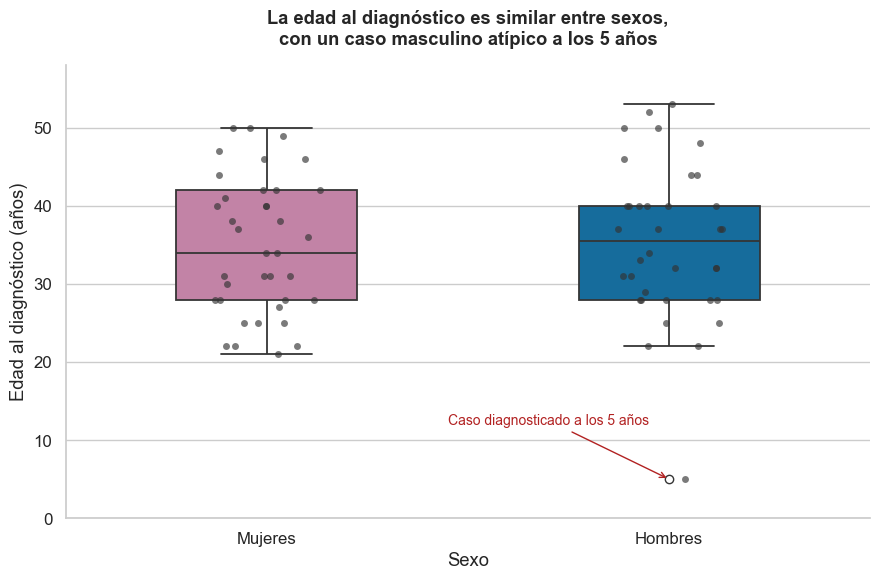

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.1
)

orden_sexo = ["Mujeres", "Hombres"]

colores_sexo = {
    "Mujeres": "#CC79A7",
    "Hombres": "#0072B2"
}

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=cohorte,
    x="SEXO",
    y="EDAD_DIAGNOSTICO",
    hue="SEXO",
    order=orden_sexo,
    palette=colores_sexo,
    width=0.45,
    linewidth=1.3,
    legend=False,
    ax=ax
)

sns.stripplot(
    data=cohorte,
    x="SEXO",
    y="EDAD_DIAGNOSTICO",
    order=orden_sexo,
    color="#333333",
    alpha=0.65,
    jitter=0.14,
    size=5,
    ax=ax
)

ax.annotate(
    "Caso diagnosticado a los 5 años",
    xy=(1, 5),
    xytext=(0.45, 12),
    arrowprops={
        "arrowstyle": "->",
        "color": "#B22222"
    },
    color="#B22222",
    fontsize=10
)

ax.set_title(
    "La edad al diagnóstico es similar entre sexos,\n"
    "con un caso masculino atípico a los 5 años",
    weight="bold",
    pad=15
)

ax.set_xlabel("Sexo")
ax.set_ylabel("Edad al diagnóstico (años)")
ax.set_ylim(0, 58)

sns.despine()
fig.tight_layout()

fig.savefig(
    FIGURAS / "edad_diagnostico_por_sexo.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    FIGURAS / "edad_diagnostico_por_sexo.pdf",
    bbox_inches="tight"
)

plt.show()

In [15]:
for archivo in sorted(FIGURAS.iterdir()):
    print(archivo.name)

edad_diagnostico_por_sexo.pdf
edad_diagnostico_por_sexo.png


## 3. Evolución temporal de un analito

Se identificarán los analitos disponibles para la cohorte antes de seleccionar
una medición. Se priorizará la hemoglobina glucosilada (HbA1c) por su relevancia
para el seguimiento de la diabetes.

In [16]:
columnas_observaciones = [
    "DATE",
    "PATIENT",
    "CODE",
    "DESCRIPTION",
    "VALUE",
    "UNITS"
]

observaciones_eda = pd.read_csv(
    RAW / "observations.csv",
    usecols=columnas_observaciones,
    low_memory=False
)

observaciones_eda["DATE"] = pd.to_datetime(
    observaciones_eda["DATE"],
    errors="coerce"
)

observaciones_diabetes = observaciones_eda.loc[
    observaciones_eda["PATIENT"].isin(ids_diabetes)
].copy()

print(
    "Observaciones totales de la cohorte:",
    len(observaciones_diabetes)
)

print(
    "Pacientes con alguna observación:",
    observaciones_diabetes["PATIENT"].nunique()
)

Observaciones totales de la cohorte: 116868
Pacientes con alguna observación: 73


In [17]:
patron_analitos = (
    "a1c|glycat|glucose|glucosa|hemoglobin"
)

analitos_candidatos = (
    observaciones_diabetes.loc[
        observaciones_diabetes["DESCRIPTION"].str.contains(
            patron_analitos,
            case=False,
            na=False,
            regex=True
        ),
        ["CODE", "DESCRIPTION", "UNITS"]
    ]
    .value_counts()
    .reset_index(name="MEDICIONES")
    .sort_values("MEDICIONES", ascending=False)
)

display(analitos_candidatos.head(20))

,CODE,DESCRIPTION,UNITS,MEDICIONES
0,2339-0,Glucose,mg/dL,2370
1,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,%,2122
2,718-7,Hemoglobin [Mass/volume] in Blood,g/dL,203
3,25428-4,Glucose [Presence] in Urine by Test strip,{nominal},126
4,5794-3,Hemoglobin [Presence] in Urine by Test strip,{nominal},126
5,5792-7,Glucose [Mass/volume] in Urine by Test strip,mg/dL,126
6,2345-7,Glucose [Mass/volume] in Serum or Plasma,mg/dL,36
7,57905-2,Hemoglobin.gastrointestinal [Presence] in Stoo...,ng/mL,8


### Preparación de las mediciones de HbA1c

Se utilizará el código LOINC `4548-4`, correspondiente a hemoglobina
glucosilada. Las mediciones se convertirán a formato numérico y se relacionarán
con la fecha de diagnóstico de cada paciente.

In [19]:
hba1c["DATE"] = pd.to_datetime(
    hba1c["DATE"],
    errors="coerce",
    utc=True
)

hba1c["FECHA_DIAGNOSTICO"] = pd.to_datetime(
    hba1c["FECHA_DIAGNOSTICO"],
    errors="coerce",
    utc=True
)

hba1c["DIAS_DESDE_DIAGNOSTICO"] = (
    hba1c["DATE"] - hba1c["FECHA_DIAGNOSTICO"]
).dt.days

print("Mediciones de HbA1c:", len(hba1c))
print(
    "Pacientes con al menos una medición:",
    hba1c["PATIENT"].nunique()
)
print(
    "Valores que no pudieron convertirse a número:",
    hba1c["HBA1C"].isna().sum()
)
print(
    "Mediciones anteriores al diagnóstico:",
    (hba1c["DIAS_DESDE_DIAGNOSTICO"] < 0).sum()
)
print(
    "Mediciones el día del diagnóstico o posteriores:",
    (hba1c["DIAS_DESDE_DIAGNOSTICO"] >= 0).sum()
)

Mediciones de HbA1c: 2122
Pacientes con al menos una medición: 73
Valores que no pudieron convertirse a número: 0
Mediciones anteriores al diagnóstico: 2
Mediciones el día del diagnóstico o posteriores: 2120


In [20]:
display(
    hba1c["HBA1C"]
    .describe(
        percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
    )
    .round(2)
)

print(
    "Periodo relativo:",
    hba1c["DIAS_DESDE_DIAGNOSTICO"].min(),
    "a",
    hba1c["DIAS_DESDE_DIAGNOSTICO"].max(),
    "días"
)

print(
    "Duplicados del mismo paciente en la misma fecha:",
    hba1c.duplicated(
        subset=["PATIENT", "DATE"]
    ).sum()
)

count    2122.00
mean        3.94
std         1.40
min         2.30
1%          2.40
25%         2.70
50%         3.80
75%         4.60
99%         7.50
max         7.70
Name: HBA1C, dtype: float64

Periodo relativo: -1099 a 27168 días
Duplicados del mismo paciente en la misma fecha: 0


### Ventana de seguimiento

Para comparar pacientes diagnosticados en diferentes años, el tiempo se
expresará en años desde el diagnóstico. Las dos mediciones anteriores al
diagnóstico se conservarán como hallazgo de calidad, pero no se incluirán en
la evolución posterior al diagnóstico.

In [21]:
hba1c_post = hba1c.loc[
    (hba1c["DIAS_DESDE_DIAGNOSTICO"] >= 0)
    & hba1c["HBA1C"].notna()
].copy()

hba1c_post["ANIO_SEGUIMIENTO"] = (
    hba1c_post["DIAS_DESDE_DIAGNOSTICO"] // 365.25
).astype(int)

resumen_anual_hba1c = (
    hba1c_post.groupby("ANIO_SEGUIMIENTO")
    .agg(
        mediciones=("HBA1C", "size"),
        pacientes=("PATIENT", "nunique"),
        mediana=("HBA1C", "median"),
        q1=("HBA1C", lambda x: x.quantile(0.25)),
        q3=("HBA1C", lambda x: x.quantile(0.75))
    )
    .reset_index()
)

display(
    resumen_anual_hba1c.head(16).round(2)
)

,ANIO_SEGUIMIENTO,mediciones,pacientes,mediana,q1,q3
0,0,16,14,6.85,6.60,7.43
1,1,17,12,6.80,6.10,7.20
2,2,16,15,6.70,6.38,7.10
3,3,24,16,6.25,3.60,6.90
4,4,21,15,6.10,3.60,6.90
5,5,19,15,6.10,3.10,6.90
6,6,20,17,6.90,5.95,7.18
7,7,25,15,6.30,3.00,6.80
8,8,34,18,5.90,3.22,6.90
9,9,29,16,4.60,3.10,5.90


In [22]:
print(
    "Mediciones con HbA1c menor de 4%:",
    (hba1c_post["HBA1C"] < 4).sum(),
    "de",
    len(hba1c_post)
)

print(
    "Pacientes con al menos una HbA1c menor de 4%:",
    hba1c_post.loc[
        hba1c_post["HBA1C"] < 4,
        "PATIENT"
    ].nunique()
)

print(
    "Pacientes con seguimiento de 0 a 10 años:",
    hba1c_post.loc[
        hba1c_post["ANIO_SEGUIMIENTO"].between(0, 10),
        "PATIENT"
    ].nunique()
)

Mediciones con HbA1c menor de 4%: 1197 de 2120
Pacientes con al menos una HbA1c menor de 4%: 26
Pacientes con seguimiento de 0 a 10 años: 34


### Evolución anual de HbA1c durante los primeros 15 años

Se presenta la mediana y el rango intercuartílico de HbA1c por año desde el
diagnóstico. El panel inferior muestra cuántos pacientes contribuyen a cada
estimación, para evitar interpretar como equivalentes años con diferente
cobertura.

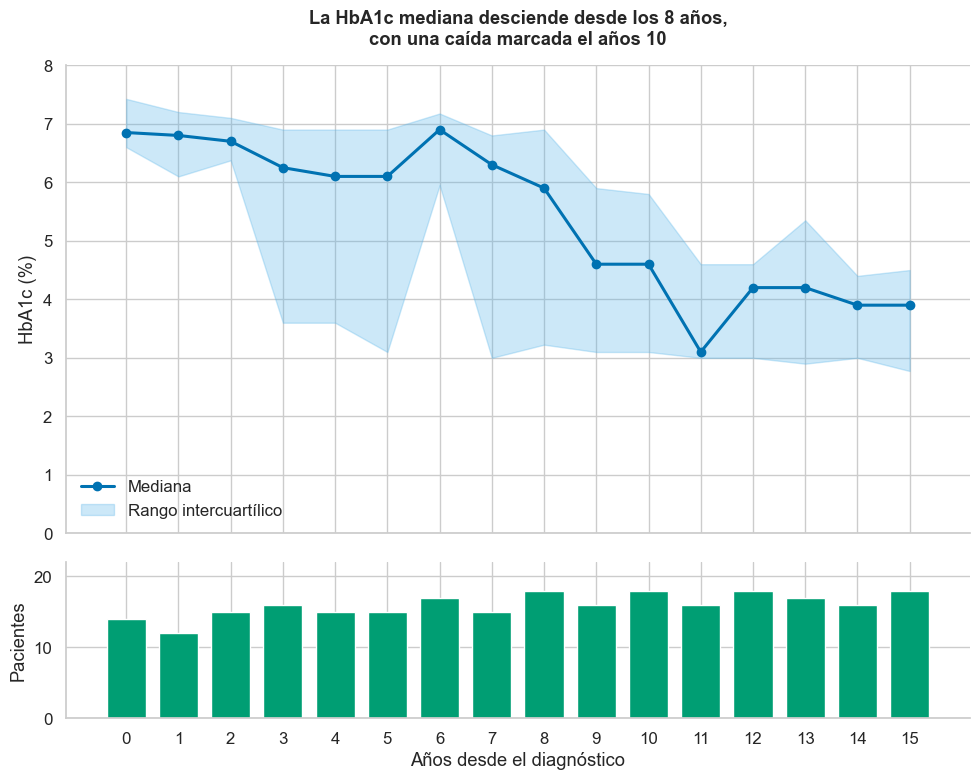

In [29]:
resumen_hba1c_15 = resumen_anual_hba1c.loc[
    resumen_anual_hba1c["ANIO_SEGUIMIENTO"].between(0, 15)
].copy()

x = resumen_hba1c_15["ANIO_SEGUIMIENTO"].to_numpy()
mediana = resumen_hba1c_15["mediana"].to_numpy()
q1 = resumen_hba1c_15["q1"].to_numpy()
q3 = resumen_hba1c_15["q3"].to_numpy()
n_pacientes = resumen_hba1c_15["pacientes"].to_numpy()

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

ax1.plot(
    x,
    mediana,
    marker="o",
    color="#0072B2",
    linewidth=2.2,
    label="Mediana"
)

ax1.fill_between(
    x,
    q1,
    q3,
    color="#56B4E9",
    alpha=0.30,
    label="Rango intercuartílico"
)

ax1.set_title(
    "La HbA1c mediana desciende desde los 8 años,\n"
    "con una caída marcada el años 10",
    weight="bold",
    pad=15
)

ax1.set_ylabel("HbA1c (%)")
ax1.set_ylim(0, 8)
ax1.legend(frameon=False, loc="lower left")

ax2.bar(
    x,
    n_pacientes,
    color="#009E73",
    width=0.75
)

ax2.set_xlabel("Años desde el diagnóstico")
ax2.set_ylabel("Pacientes")
ax2.set_xticks(range(0, 16))
ax2.set_ylim(0, max(n_pacientes) + 4)

sns.despine()
fig.tight_layout()

fig.savefig(
    FIGURAS / "evolucion_hba1c_15_anios.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    FIGURAS / "evolucion_hba1c_15_anios.pdf",
    bbox_inches="tight"
)

plt.show()



**Interpretación:** La mediana de HbA1c se mantuvo entre 6.1% y 6.9% durante
los primeros seis años posteriores al diagnóstico. Desde el sexto año se
observó una tendencia descendente, con una caída más marcada entre los años
8 y 9, cuando la mediana pasó de 5.9% a 4.6%. Cada estimación anual incluyó
entre 12 y 18 pacientes. Como la composición de pacientes cambia entre años,
este patrón no demuestra por sí solo una mejoría individual sostenida y podría
estar influido por diferencias en el seguimiento o por la generación de los
datos sintéticos.

## 4. Comorbilidades más frecuentes

Se calculará la frecuencia de cada condición clínica entre los pacientes de la
cohorte. Cada condición contará una sola vez por paciente, aunque tenga varios
registros. El diagnóstico utilizado para definir la cohorte (`Diabetes`) será
excluido del conteo.

In [30]:
condiciones_cohorte = conditions.loc[
    conditions["PATIENT"].isin(ids_diabetes)
].copy()

condiciones_unicas = (
    condiciones_cohorte[
        ["PATIENT", "DESCRIPTION"]
    ]
    .dropna()
    .drop_duplicates()
)

condiciones_unicas = condiciones_unicas.loc[
    ~condiciones_unicas["DESCRIPTION"].eq("Diabetes")
]

comorbilidades = (
    condiciones_unicas.groupby("DESCRIPTION")
    .agg(
        pacientes=("PATIENT", "nunique")
    )
    .reset_index()
)

comorbilidades["prevalencia_pct"] = (
    comorbilidades["pacientes"]
    / len(cohorte)
    * 100
)

comorbilidades = comorbilidades.sort_values(
    ["pacientes", "DESCRIPTION"],
    ascending=[False, True]
)

display(
    comorbilidades.head(20).round(
        {"prevalencia_pct": 1}
    )
)

,DESCRIPTION,pacientes,prevalencia_pct
125,Stress (finding),72,98.6
58,Hypertriglyceridemia (disorder),71,97.3
76,Metabolic syndrome X (disorder),68,93.2
47,Full-time employment (finding),66,90.4
120,Social isolation (finding),64,87.7
97,Part-time employment (finding),61,83.6
70,Limited social contact (finding),58,79.5
134,Victim of intimate partner abuse (finding),55,75.3
135,Viral sinusitis (disorder),55,75.3
6,Anemia (disorder),53,72.6


In [31]:
print("Pacientes de la cohorte:", len(cohorte))

print(
    "Pacientes con al menos otra condición:",
    condiciones_unicas["PATIENT"].nunique()
)

print(
    "Condiciones diferentes encontradas:",
    condiciones_unicas["DESCRIPTION"].nunique()
)

Pacientes de la cohorte: 73
Pacientes con al menos otra condición: 73
Condiciones diferentes encontradas: 137


### Refinamiento de la definición de comorbilidad

El archivo `conditions.csv` mezcla enfermedades con hallazgos sociales,
laborales y educativos. Para evitar clasificarlos incorrectamente como
comorbilidades, se incluirán únicamente condiciones que no estén etiquetadas
como `(finding)` y que estuvieran activas en la fecha del diagnóstico de
diabetes.

In [33]:
condiciones_temporales = condiciones_cohorte.copy()

condiciones_temporales["START"] = pd.to_datetime(
    condiciones_temporales["START"],
    errors="coerce",
    utc=True
)

condiciones_temporales["STOP"] = pd.to_datetime(
    condiciones_temporales["STOP"],
    errors="coerce",
    utc=True
)

condiciones_temporales = condiciones_temporales.merge(
    diagnosticos_base,
    left_on="PATIENT",
    right_on="Id",
    how="left",
    validate="many_to_one"
)

condiciones_temporales["FECHA_DIAGNOSTICO"] = pd.to_datetime(
    condiciones_temporales["FECHA_DIAGNOSTICO"],
    errors="coerce",
    utc=True
)

activas_al_diagnostico = condiciones_temporales.loc[
    (condiciones_temporales["START"]
     <= condiciones_temporales["FECHA_DIAGNOSTICO"])
    &
    (
        condiciones_temporales["STOP"].isna()
        |
        (condiciones_temporales["STOP"]
         >= condiciones_temporales["FECHA_DIAGNOSTICO"])
    )
].copy()

In [34]:
comorbilidades_clinicas = activas_al_diagnostico.loc[
    ~activas_al_diagnostico["DESCRIPTION"].eq("Diabetes")
    &
    ~activas_al_diagnostico["DESCRIPTION"].str.contains(
        r"\(finding\)",
        case=False,
        na=False,
        regex=True
    )
].copy()

comorbilidades_unicas = (
    comorbilidades_clinicas[
        ["PATIENT", "DESCRIPTION"]
    ]
    .drop_duplicates()
)

frecuencia_comorbilidades = (
    comorbilidades_unicas.groupby("DESCRIPTION")
    .agg(pacientes=("PATIENT", "nunique"))
    .reset_index()
)

frecuencia_comorbilidades["prevalencia_pct"] = (
    frecuencia_comorbilidades["pacientes"]
    / len(cohorte)
    * 100
)

frecuencia_comorbilidades = (
    frecuencia_comorbilidades.sort_values(
        ["pacientes", "DESCRIPTION"],
        ascending=[False, True]
    )
)

display(
    frecuencia_comorbilidades.head(15).round(
        {"prevalencia_pct": 1}
    )
)

print(
    "Pacientes con alguna comorbilidad clínica activa:",
    comorbilidades_unicas["PATIENT"].nunique()
)

,DESCRIPTION,pacientes,prevalencia_pct
16,Hypertension,38,52.1
0,Anemia (disorder),36,49.3
24,Prediabetes,24,32.9
21,Miscarriage in first trimester,12,16.4
9,Chronic sinusitis (disorder),10,13.7
12,Diabetic renal disease (disorder),5,6.8
1,Appendicitis,4,5.5
5,Chronic kidney disease stage 1 (disorder),4,5.5
13,History of appendectomy,4,5.5
7,Chronic pain,3,4.1


Pacientes con alguna comorbilidad clínica activa: 65


In [35]:
excluir_como_comorbilidad = [
    "Prediabetes",
    "Miscarriage in first trimester",
    "Appendicitis",
    "History of appendectomy",
    "Impacted molars",
    "Refugee (person)"
]

comorbilidades_finales = frecuencia_comorbilidades.loc[
    ~frecuencia_comorbilidades["DESCRIPTION"].isin(
        excluir_como_comorbilidad
    )
].copy()

top_10_comorbilidades = (
    comorbilidades_finales
    .head(10)
    .sort_values("prevalencia_pct")
)

display(
    top_10_comorbilidades.sort_values(
        "prevalencia_pct",
        ascending=False
    ).round({"prevalencia_pct": 1})
)

,DESCRIPTION,pacientes,prevalencia_pct
16,Hypertension,38,52.1
0,Anemia (disorder),36,49.3
9,Chronic sinusitis (disorder),10,13.7
12,Diabetic renal disease (disorder),5,6.8
5,Chronic kidney disease stage 1 (disorder),4,5.5
7,Chronic pain,3,4.1
22,Neuropathy due to type 2 diabetes mellitus (di...,3,4.1
4,Chronic intractable migraine without aura,2,2.7
10,Coronary Heart Disease,2,2.7
27,Sepsis (disorder),2,2.7


### Criterios adicionales de exclusión

Se excluyeron prediabetes, eventos obstétricos, antecedentes quirúrgicos,
condiciones odontológicas y características sociales. Esta clasificación es
una decisión operativa reproducible, ya que el archivo no proporciona una
variable directa que distinga enfermedades crónicas de eventos resueltos.

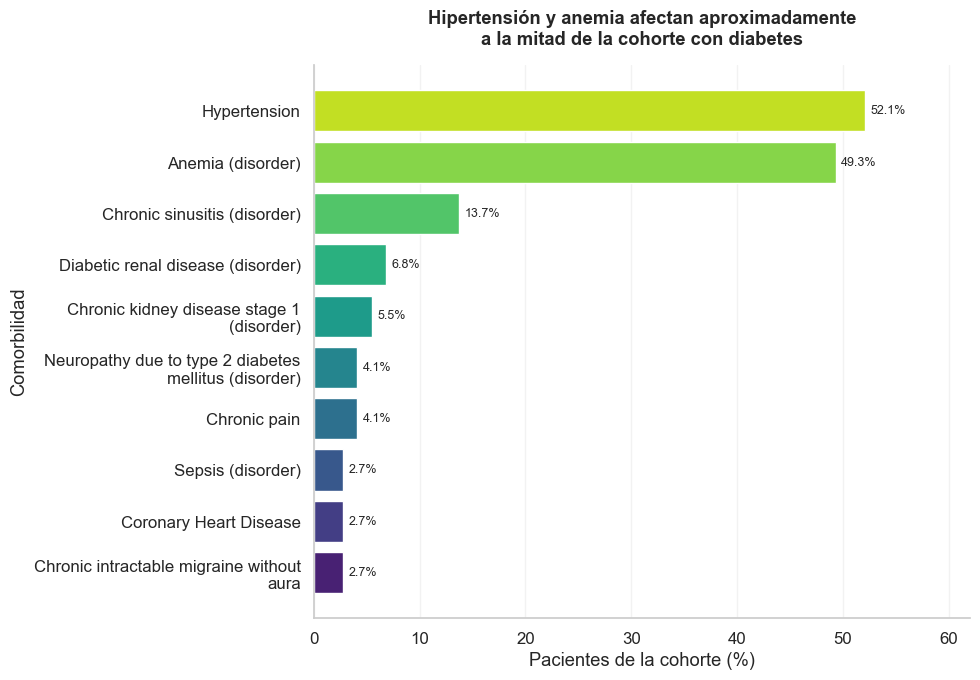

In [36]:
import textwrap

etiquetas = [
    "\n".join(textwrap.wrap(texto, width=38))
    for texto in top_10_comorbilidades["DESCRIPTION"]
]

fig, ax = plt.subplots(figsize=(10, 7))

barras = ax.barh(
    etiquetas,
    top_10_comorbilidades["prevalencia_pct"],
    color=sns.color_palette(
        "viridis",
        len(top_10_comorbilidades)
    )
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in top_10_comorbilidades[
            "prevalencia_pct"
        ]
    ],
    padding=4,
    fontsize=9
)

ax.set_title(
    "Hipertensión y anemia afectan aproximadamente\n"
    "a la mitad de la cohorte con diabetes",
    weight="bold",
    pad=15
)

ax.set_xlabel("Pacientes de la cohorte (%)")
ax.set_ylabel("Comorbilidad")
ax.set_xlim(
    0,
    top_10_comorbilidades["prevalencia_pct"].max() + 10
)

ax.xaxis.grid(True, alpha=0.25)
ax.yaxis.grid(False)

sns.despine()
fig.tight_layout()

fig.savefig(
    FIGURAS / "comorbilidades_mas_frecuentes.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    FIGURAS / "comorbilidades_mas_frecuentes.pdf",
    bbox_inches="tight"
)

plt.show()

### Interpretación

En la cohorte de 73 pacientes con diabetes, la hipertensión fue la 
comorbilidad más frecuente, al presentarse en 38 pacientes (52.1%), 
seguida de la anemia, identificada en 36 pacientes (49.3%). La sinusitis 
crónica mostró una prevalencia considerablemente menor (13.7%).

También se identificaron complicaciones asociadas con la diabetes, como 
la enfermedad renal diabética (6.8%), la enfermedad renal crónica en 
estadio 1 (5.5%) y la neuropatía diabética (4.1%). Las demás condiciones 
presentaron prevalencias inferiores al 5%.

Estos resultados sugieren que la hipertensión y la anemia representan 
las principales condiciones concomitantes en esta cohorte y podrían 
requerir especial atención durante el seguimiento clínico. Los 
porcentajes no son mutuamente excluyentes, debido a que un mismo 
paciente puede presentar más de una comorbilidad.

In [37]:
%whos DataFrame

Variable                    Type         Data/Info
--------------------------------------------------
activas_al_diagnostico      DataFrame                             <...>n\n[608 rows x 8 columns]
analitos_candidatos         DataFrame          CODE               <...>    36  \n7           8  
cohorte                     DataFrame                             <...>n\n[73 rows x 28 columns]
comorbilidades              DataFrame                             <...>n\n[137 rows x 3 columns]
comorbilidades_clinicas     DataFrame                             <...>n\n[172 rows x 8 columns]
comorbilidades_finales      DataFrame                             <...>  \n32         1.369863  
comorbilidades_unicas       DataFrame                             <...>n\n[172 rows x 2 columns]
condiciones_cohorte         DataFrame                START        <...>\n[7014 rows x 6 columns]
condiciones_temporales      DataFrame                             <...>\n[7014 rows x 8 columns]
condiciones_unicas       

In [38]:
print("Columnas de hba1c_post:")
display(
    hba1c_post.dtypes
        .rename("tipo")
        .to_frame()
)

display(hba1c_post.head(3))

Columnas de hba1c_post:


,tipo
DATE,"datetime64[ns, UTC]"
PATIENT,object
CODE,object
DESCRIPTION,object
VALUE,object
UNITS,object
HBA1C,float64
Id,object
FECHA_DIAGNOSTICO,"datetime64[ns, UTC]"
DIAS_DESDE_DIAGNOSTICO,int64


,DATE,PATIENT,CODE,DESCRIPTION,VALUE,UNITS,HBA1C,Id,FECHA_DIAGNOSTICO,DIAS_DESDE_DIAGNOSTICO,ANIO_SEGUIMIENTO
0,2019-08-21 19:44:25+00:00,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,6.6,%,6.6,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,2019-08-21 00:00:00+00:00,0,0
1,2020-04-01 19:44:25+00:00,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,6.6,%,6.6,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,2019-08-21 00:00:00+00:00,224,0
2,2012-11-29 04:22:51+00:00,1cfa5a70-7f3c-4227-5cf1-e182fcff4cd4,4548-4,Hemoglobin A1c/Hemoglobin.total in Blood,6.1,%,6.1,1cfa5a70-7f3c-4227-5cf1-e182fcff4cd4,2000-09-28 00:00:00+00:00,4445,12


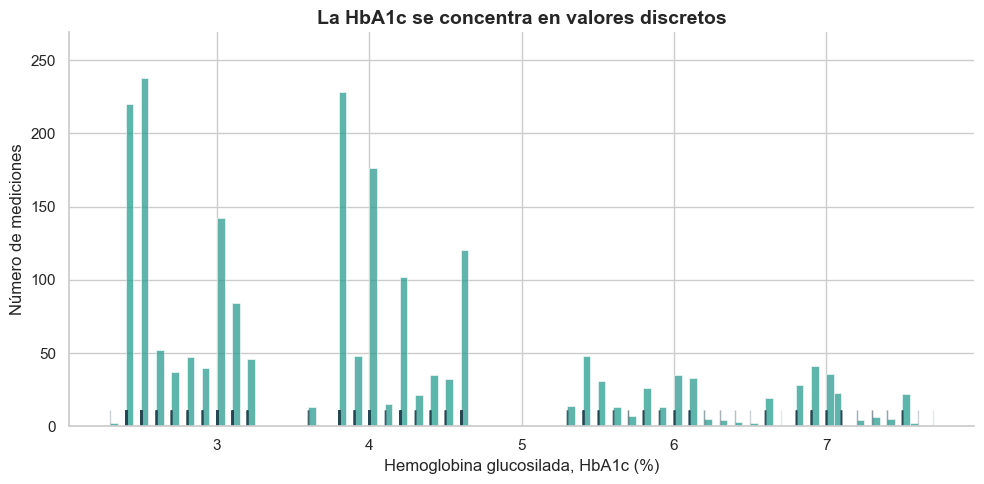

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=hba1c_post,
    x="HBA1C",
    binwidth=0.05,
    color="#2A9D8F",
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)

sns.rugplot(
    data=hba1c_post,
    x="HBA1C",
    color="#264653",
    alpha=0.12,
    height=0.04,
    ax=ax
)

ax.set_title(
    "La HbA1c se concentra en valores discretos",
    fontsize=14,
    weight="bold"
)
ax.set_xlabel("Hemoglobina glucosilada, HbA1c (%)")
ax.set_ylabel("Número de mediciones")

sns.despine()
plt.tight_layout()
plt.show()

In [40]:
incrementos_decima = (
    ((hba1c_post["HBA1C"] * 10) % 1)
    .abs()
    .lt(1e-9)
    .mean() * 100
)

print(
    f"Mediciones registradas exactamente en décimas: "
    f"{incrementos_decima:.1f}%"
)

Mediciones registradas exactamente en décimas: 100.0%


#### Problema de calidad 1: precisión limitada de la HbA1c

La distribución gráfica mostró picos estrechos y separados, en lugar de una
distribución continua. Al comprobar la precisión de los registros, se encontró
que el 100% de las mediciones de HbA1c estaba expresado exactamente con una
cifra decimal.

Este patrón sugiere redondeo o cuantización de los valores, probablemente
relacionado con el origen sintético de los datos. Aunque no implica que las
mediciones sean inválidas, limita su precisión y puede producir patrones
artificiales en análisis estadísticos y gráficos. Este problema no resulta
evidente mediante `describe()`.

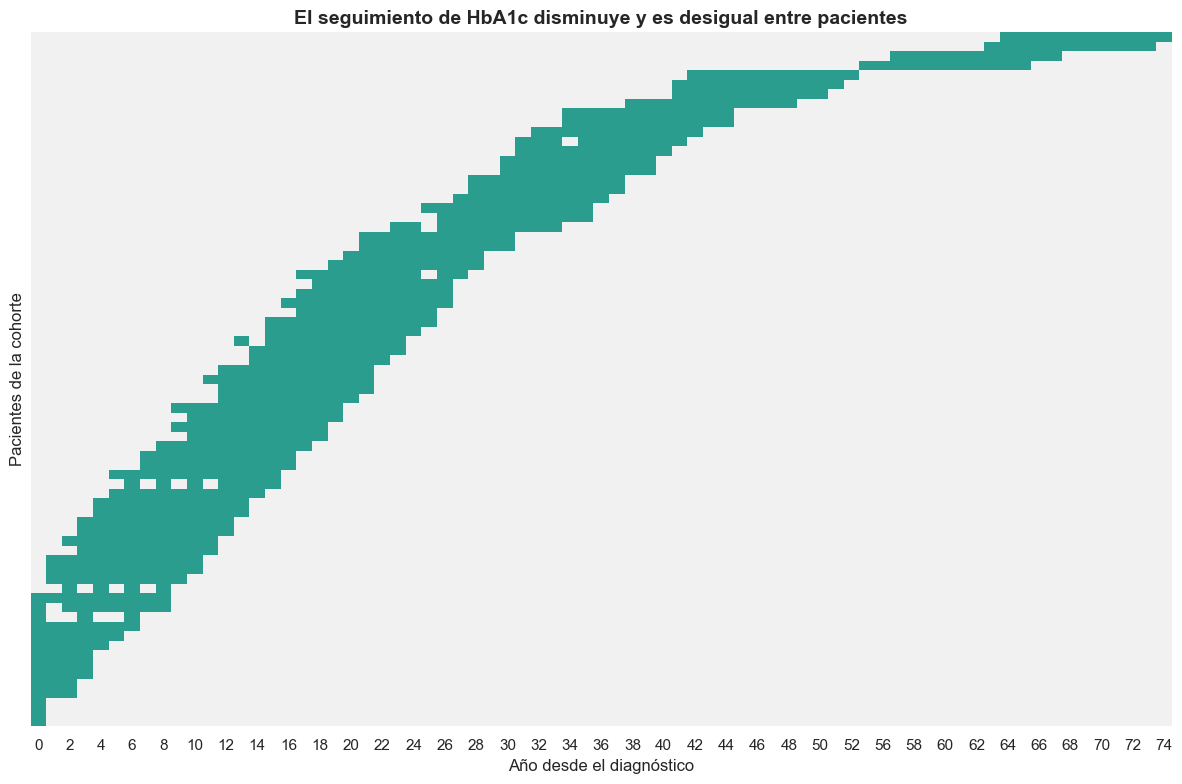

In [41]:
# Presencia de mediciones por paciente y año de seguimiento
matriz_seguimiento = (
    hba1c_post
    .groupby(["PATIENT", "ANIO_SEGUIMIENTO"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .astype(int)
)

# Ordenar a los pacientes según su último año con medición
ultimo_anio = matriz_seguimiento.apply(
    lambda fila: fila[fila.eq(1)].index.max()
    if fila.eq(1).any() else -1,
    axis=1
)

matriz_seguimiento = matriz_seguimiento.loc[
    ultimo_anio.sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    matriz_seguimiento,
    cmap=["#F1F1F1", "#2A9D8F"],
    cbar=False,
    linewidths=0,
    ax=ax
)

ax.set_title(
    "El seguimiento de HbA1c disminuye y es desigual entre pacientes",
    fontsize=14,
    weight="bold"
)
ax.set_xlabel("Año desde el diagnóstico")
ax.set_ylabel("Pacientes de la cohorte")
ax.set_yticks([])

plt.tight_layout()
plt.show()

In [42]:
resumen_seguimiento = pd.Series({
    "Pacientes": matriz_seguimiento.shape[0],
    "Máximo año observado": matriz_seguimiento.columns.max(),
    "Mediana de años con medición": (
        matriz_seguimiento.sum(axis=1).median()
    ),
    "Pacientes con 5 años o más": (
        matriz_seguimiento.sum(axis=1).ge(5).sum()
    ),
    "Pacientes con 10 años o más": (
        matriz_seguimiento.sum(axis=1).ge(10).sum()
    ),
    "Pacientes con huecos temporales": (
        matriz_seguimiento.apply(
            lambda fila: (
                fila.loc[
                    fila.eq(1).idxmax():
                    fila.iloc[::-1].eq(1).idxmax()
                ].eq(0).any()
            ),
            axis=1
        ).sum()
    )
})

display(resumen_seguimiento.to_frame("resultado"))

,resultado
Pacientes,73.0
Máximo año observado,74.0
Mediana de años con medición,10.0
Pacientes con 5 años o más,63.0
Pacientes con 10 años o más,49.0
Pacientes con huecos temporales,8.0


#### Problema de calidad 2: seguimiento temporal desigual

El mapa de calor reveló diferencias importantes en la duración y
continuidad del seguimiento. Aunque los 73 pacientes tuvieron mediciones
de HbA1c, la mediana fue de 10 años con registros. Un total de 63 pacientes
(86.3%) presentó cinco años o más de mediciones y 49 (67.1%) alcanzó diez
años o más.

Además, 8 pacientes (11.0%) tuvieron huecos temporales, es decir, años
intermedios sin mediciones registradas. El máximo alcanzó 74 años desde
el diagnóstico, por lo que también sería conveniente validar la fecha
inicial de esos seguimientos excepcionalmente largos.

En consecuencia, las estimaciones de los años tardíos se basan en un
número menor y potencialmente distinto de pacientes. Esto puede generar
sesgo de seguimiento y producir cambios aparentes en la HbA1c que no
representen una evolución clínica real. Este patrón no resulta evidente
en un `describe()` general, pues requiere examinar conjuntamente al
paciente y el momento de cada medición.

In [43]:
print("Columnas de cohorte:")
print(cohorte.columns.tolist())

print("\nColumnas de resumen_anual_hba1c:")
print(resumen_anual_hba1c.columns.tolist())

print("\nColumnas de top_10_comorbilidades:")
print(top_10_comorbilidades.columns.tolist())

Columnas de cohorte:
['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'FECHA_DIAGNOSTICO', 'EDAD_DIAGNOSTICO', 'SEXO']

Columnas de resumen_anual_hba1c:
['ANIO_SEGUIMIENTO', 'mediciones', 'pacientes', 'mediana', 'q1', 'q3']

Columnas de top_10_comorbilidades:
['DESCRIPTION', 'pacientes', 'prevalencia_pct']


Figura exportada correctamente en PNG y PDF.


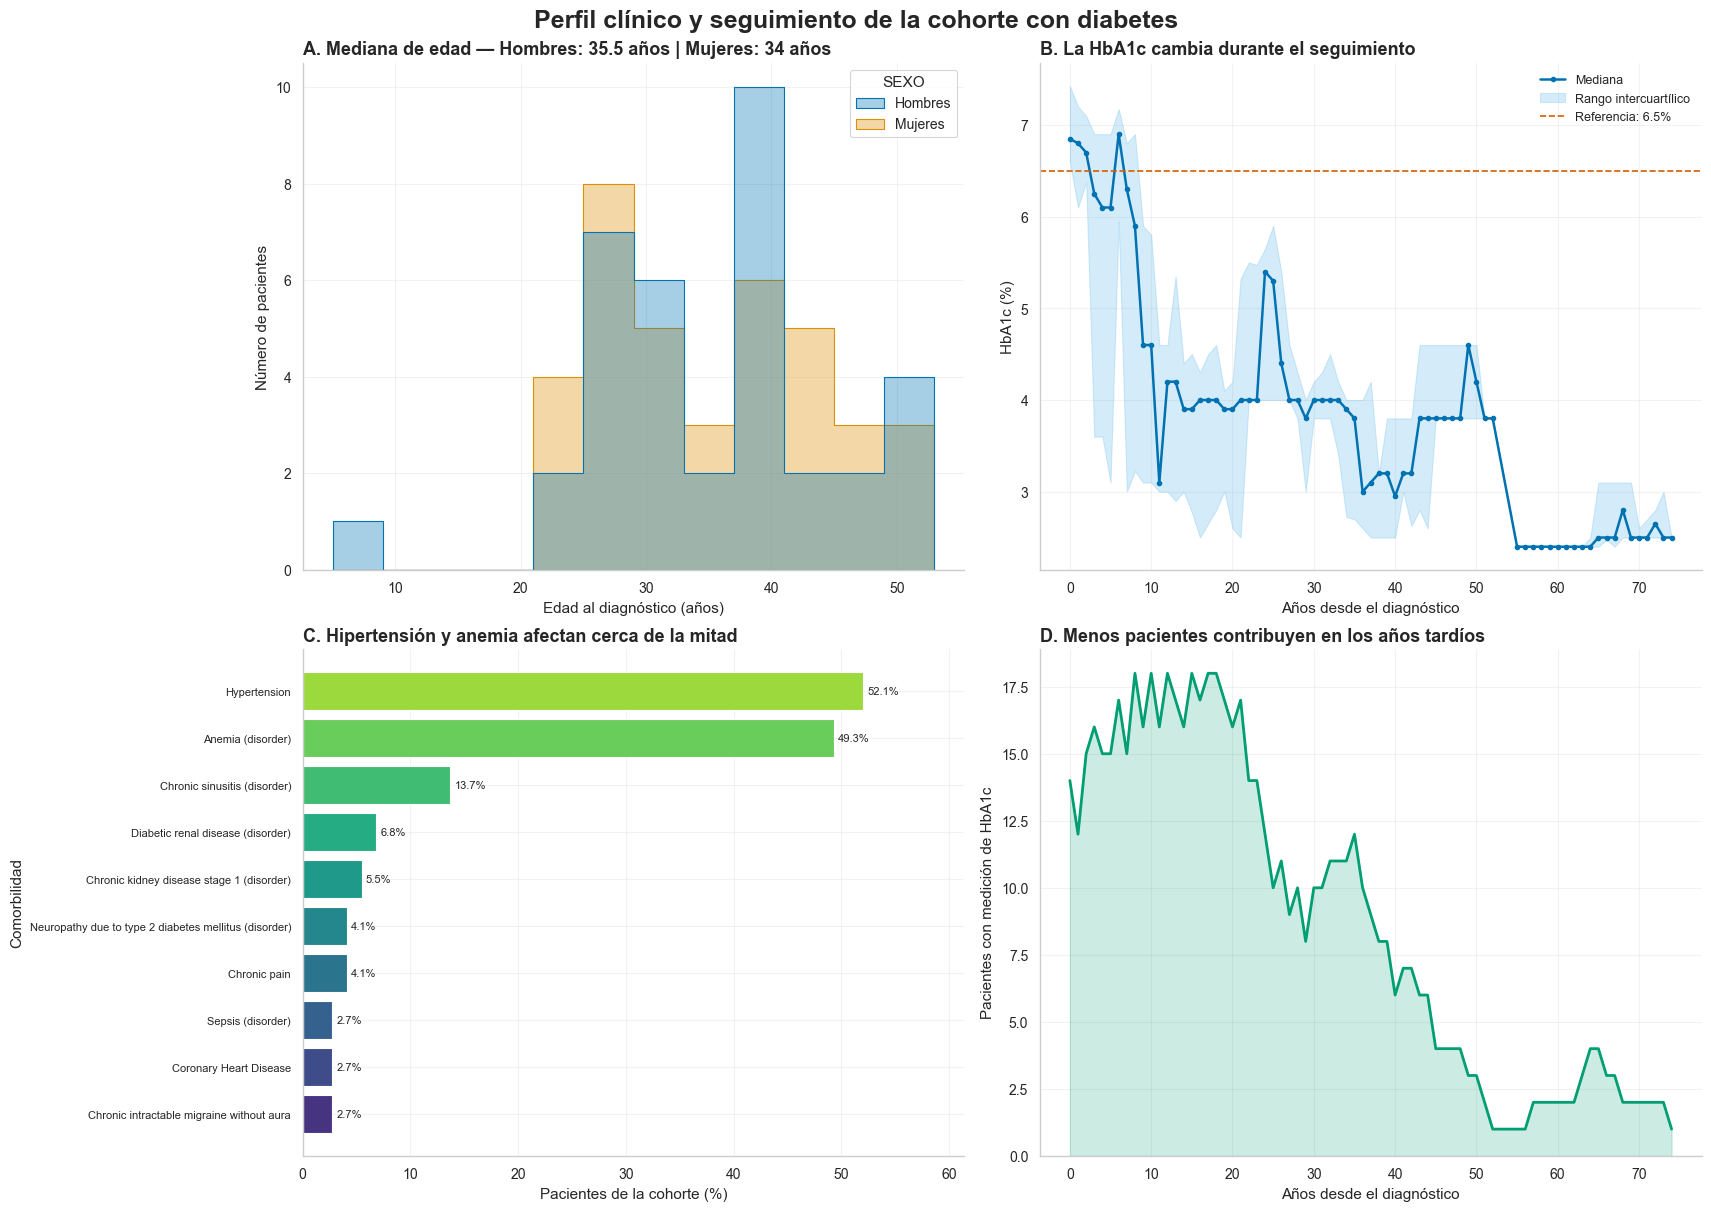

In [63]:
# =========================================================
# FIGURA MULTIPANEL 2 × 2
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo general de publicación
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.15
)

# =========================================================
# 1. PREPARAR LOS DATOS
# =========================================================

# Convertir la edad a formato numérico
cohorte["EDAD_DIAGNOSTICO"] = pd.to_numeric(
    cohorte["EDAD_DIAGNOSTICO"],
    errors="coerce"
)

# Calcular la mediana de edad por sexo
medianas_edad = (
    cohorte
    .dropna(subset=["EDAD_DIAGNOSTICO", "SEXO"])
    .groupby("SEXO")["EDAD_DIAGNOSTICO"]
    .median()
    .round(1)
)

# Crear texto con las medianas para el título
texto_mediana_edad = " | ".join(
    f"{sexo}: {edad:g} años"
    for sexo, edad in medianas_edad.items()
)

# Ordenar los datos temporales
hba1c_grafica = (
    resumen_anual_hba1c
    .sort_values("ANIO_SEGUIMIENTO")
    .copy()
)

# Asegurar que las columnas sean numéricas
columnas_numericas = [
    "ANIO_SEGUIMIENTO",
    "mediciones",
    "pacientes",
    "mediana",
    "q1",
    "q3"
]

for columna in columnas_numericas:
    hba1c_grafica[columna] = pd.to_numeric(
        hba1c_grafica[columna],
        errors="coerce"
    )

# Eliminar filas incompletas necesarias para la gráfica
hba1c_grafica = hba1c_grafica.dropna(
    subset=[
        "ANIO_SEGUIMIENTO",
        "pacientes",
        "mediana",
        "q1",
        "q3"
    ]
)

# Ordenar las comorbilidades de menor a mayor
comorb_grafica = (
    top_10_comorbilidades
    .sort_values("prevalencia_pct", ascending=True)
    .copy()
)

comorb_grafica["prevalencia_pct"] = pd.to_numeric(
    comorb_grafica["prevalencia_pct"],
    errors="coerce"
)

comorb_grafica = comorb_grafica.dropna(
    subset=["DESCRIPTION", "prevalencia_pct"]
)

# =========================================================
# 2. CREAR LA FIGURA Y LOS CUATRO PANELES
# =========================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(17, 12),
    constrained_layout=True
)

ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# =========================================================
# PANEL A: EDAD AL DIAGNÓSTICO POR SEXO
# =========================================================

sns.histplot(
    data=cohorte,
    x="EDAD_DIAGNOSTICO",
    hue="SEXO",
    bins=12,
    element="step",
    stat="count",
    common_norm=False,
    palette="colorblind",
    alpha=0.35,
    ax=ax1
)

ax1.set_title(
    f"A. Mediana de edad — {texto_mediana_edad}",
    loc="left",
    fontsize=13,
    weight="bold"
)

ax1.set_xlabel(
    "Edad al diagnóstico (años)",
    fontsize=11
)

ax1.set_ylabel(
    "Número de pacientes",
    fontsize=11
)

# =========================================================
# PANEL B: EVOLUCIÓN TEMPORAL DE LA HbA1c
# =========================================================

ax2.plot(
    hba1c_grafica["ANIO_SEGUIMIENTO"].to_numpy(),
    hba1c_grafica["mediana"].to_numpy(),
    color="#0072B2",
    marker="o",
    markersize=3,
    linewidth=1.8,
    label="Mediana"
)

ax2.fill_between(
    hba1c_grafica["ANIO_SEGUIMIENTO"].to_numpy(),
    hba1c_grafica["q1"].to_numpy(),
    hba1c_grafica["q3"].to_numpy(),
    color="#56B4E9",
    alpha=0.25,
    label="Rango intercuartílico"
)

# Línea de referencia diagnóstica
ax2.axhline(
    y=6.5,
    color="#D55E00",
    linestyle="--",
    linewidth=1.2,
    label="Referencia: 6.5%"
)

ax2.set_title(
    "B. La HbA1c cambia durante el seguimiento",
    loc="left",
    fontsize=13,
    weight="bold"
)

ax2.set_xlabel(
    "Años desde el diagnóstico",
    fontsize=11
)

ax2.set_ylabel(
    "HbA1c (%)",
    fontsize=11
)

ax2.legend(
    frameon=False,
    fontsize=9
)

# =========================================================
# PANEL C: COMORBILIDADES MÁS FRECUENTES
# =========================================================

colores = plt.cm.viridis(
    np.linspace(
        0.15,
        0.85,
        len(comorb_grafica)
    )
)

barras = ax3.barh(
    comorb_grafica["DESCRIPTION"],
    comorb_grafica["prevalencia_pct"],
    color=colores
)

# Agregar el porcentaje al final de cada barra
ax3.bar_label(
    barras,
    labels=[
        f"{valor:.1f}%"
        for valor in comorb_grafica["prevalencia_pct"]
    ],
    padding=3,
    fontsize=8
)

ax3.set_title(
    "C. Hipertensión y anemia afectan cerca de la mitad",
    loc="left",
    fontsize=13,
    weight="bold"
)

ax3.set_xlabel(
    "Pacientes de la cohorte (%)",
    fontsize=11
)

ax3.set_ylabel(
    "Comorbilidad",
    fontsize=11
)

# Dar espacio para las etiquetas porcentuales
ax3.set_xlim(
    0,
    comorb_grafica["prevalencia_pct"].max() * 1.18
)

ax3.tick_params(
    axis="y",
    labelsize=8
)

# =========================================================
# PANEL D: PACIENTES DISPONIBLES POR AÑO
# =========================================================

ax4.plot(
    hba1c_grafica["ANIO_SEGUIMIENTO"].to_numpy(),
    hba1c_grafica["pacientes"].to_numpy(),
    color="#009E73",
    linewidth=2
)

ax4.fill_between(
    hba1c_grafica["ANIO_SEGUIMIENTO"].to_numpy(),
    hba1c_grafica["pacientes"].to_numpy(),
    0,
    color="#009E73",
    alpha=0.20
)

ax4.set_title(
    "D. Menos pacientes contribuyen en los años tardíos",
    loc="left",
    fontsize=13,
    weight="bold"
)

ax4.set_xlabel(
    "Años desde el diagnóstico",
    fontsize=11
)

ax4.set_ylabel(
    "Pacientes con medición de HbA1c",
    fontsize=11
)

ax4.set_ylim(bottom=0)

# =========================================================
# 3. AJUSTES FINALES
# =========================================================

for ax in axes.flatten():
    sns.despine(ax=ax)
    ax.grid(
        axis="both",
        alpha=0.25
    )

fig.suptitle(
    "Perfil clínico y seguimiento de la cohorte con diabetes",
    fontsize=18,
    weight="bold"
)
# =========================================================
# 4. EXPORTAR LA FIGURA FINAL
# =========================================================

from pathlib import Path

# Crear la carpeta figuras si todavía no existe
carpeta_figuras = Path("figuras")
carpeta_figuras.mkdir(exist_ok=True)

# Guardar PNG con resolución de publicación
fig.savefig(
    carpeta_figuras / "figura_multipanel_cohorte.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Guardar PDF vectorial
fig.savefig(
    carpeta_figuras / "figura_multipanel_cohorte.pdf",
    format="pdf",
    bbox_inches="tight",
    facecolor="white"
)

print("Figura exportada correctamente en PNG y PDF.")
plt.show()

### Interpretación de la figura multipanel

La edad al diagnóstico fue semejante entre ambos sexos: la mediana fue de
35.5 años en hombres y de 34 años en mujeres. Sin embargo, la distribución
muestra que la cohorte incluye pacientes diagnosticados en etapas muy
diferentes de la vida.

La mediana de HbA1c presentó una disminución durante el seguimiento. En los
años tardíos alcanzó valores inusualmente bajos, cercanos a 2.5%, que deben
interpretarse con cautela porque podrían reflejar características de los
datos sintéticos o la reducción del número de pacientes disponibles.

La hipertensión y la anemia fueron las comorbilidades principales, con
prevalencias de 52.1% y 49.3%, respectivamente. Las demás condiciones
presentaron frecuencias considerablemente menores.

Finalmente, el número de pacientes con mediciones de HbA1c disminuyó
conforme aumentaron los años desde el diagnóstico. Por ello, los valores
de los periodos tardíos representan a un subconjunto pequeño de la cohorte
y no deben interpretarse como la trayectoria de los 73 pacientes.

## 6. Comparación entre Matplotlib, Seaborn y Plotly

Se reprodujo la evolución temporal de la HbA1c con tres bibliotecas para
comparar el esfuerzo de programación, el control sobre la presentación
y el grado de interactividad obtenido.

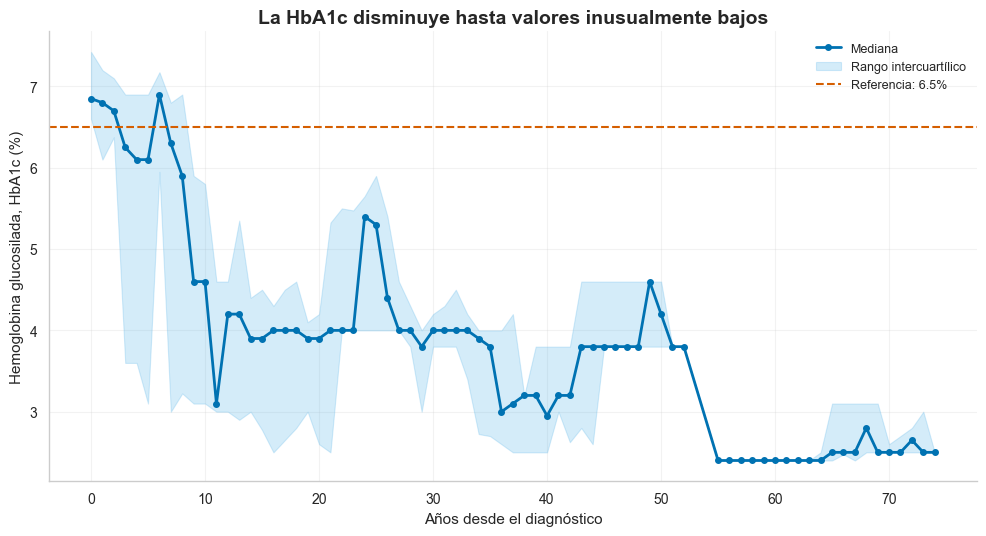

In [47]:
# =========================================================
# VERSIÓN 1: MATPLOTLIB PURO
# =========================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))

# Línea de la mediana
ax.plot(
    hba1c_grafica["ANIO_SEGUIMIENTO"].to_numpy(),
    hba1c_grafica["mediana"].to_numpy(),
    color="#0072B2",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Mediana"
)

# Rango intercuartílico
ax.fill_between(
    hba1c_grafica["ANIO_SEGUIMIENTO"].to_numpy(),
    hba1c_grafica["q1"].to_numpy(),
    hba1c_grafica["q3"].to_numpy(),
    color="#56B4E9",
    alpha=0.25,
    label="Rango intercuartílico"
)

# Referencia diagnóstica
ax.axhline(
    y=6.5,
    color="#D55E00",
    linestyle="--",
    linewidth=1.5,
    label="Referencia: 6.5%"
)

ax.set_title(
    "La HbA1c disminuye hasta valores inusualmente bajos",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel(
    "Años desde el diagnóstico",
    fontsize=11
)

ax.set_ylabel(
    "Hemoglobina glucosilada, HbA1c (%)",
    fontsize=11
)

ax.legend(
    frameon=False,
    fontsize=9
)

ax.grid(
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

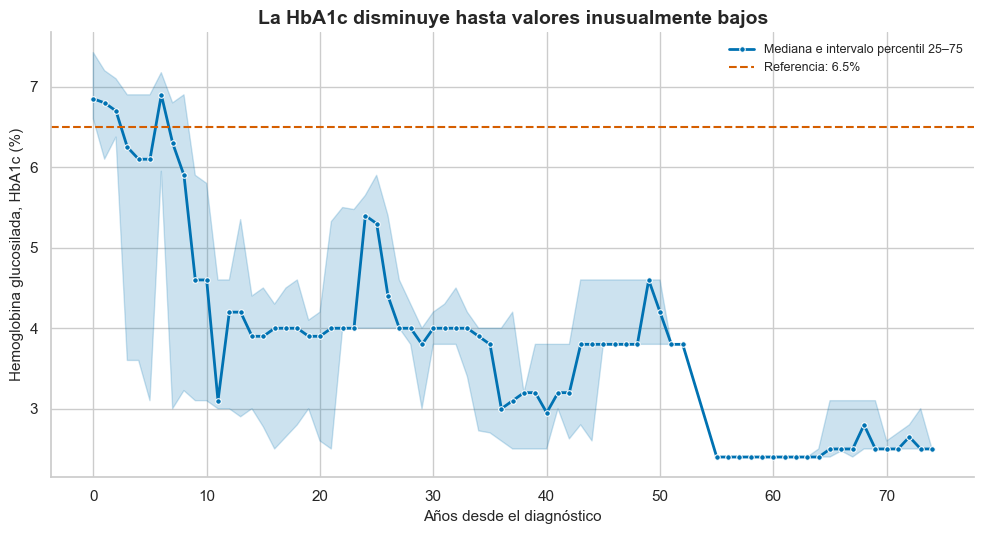

In [48]:
# =========================================================
# VERSIÓN 2: SEABORN
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.lineplot(
    data=hba1c_post,
    x="ANIO_SEGUIMIENTO",
    y="HBA1C",
    estimator=np.median,
    errorbar=("pi", 50),
    color="#0072B2",
    marker="o",
    markersize=4,
    linewidth=2,
    err_style="band",
    ax=ax,
    label="Mediana e intervalo percentil 25–75"
)

ax.axhline(
    y=6.5,
    color="#D55E00",
    linestyle="--",
    linewidth=1.5,
    label="Referencia: 6.5%"
)

ax.set_title(
    "La HbA1c disminuye hasta valores inusualmente bajos",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel(
    "Años desde el diagnóstico",
    fontsize=11
)

ax.set_ylabel(
    "Hemoglobina glucosilada, HbA1c (%)",
    fontsize=11
)

ax.legend(
    frameon=False,
    fontsize=9
)

sns.despine()

plt.tight_layout()
plt.show()

In [58]:
# =========================================================
# VERSIÓN 3: PLOTLY
# =========================================================

import plotly.graph_objects as go

# Ordenar nuevamente los datos por año
plotly_hba1c = (
    hba1c_grafica
    .sort_values("ANIO_SEGUIMIENTO")
    .copy()
)

fig_plotly = go.Figure()

# Límite superior del rango intercuartílico
fig_plotly.add_trace(
    go.Scatter(
        x=plotly_hba1c["ANIO_SEGUIMIENTO"],
        y=plotly_hba1c["q3"],
        mode="lines",
        line=dict(width=0),
        hoverinfo="skip",
        showlegend=False,
        name="Q3"
    )
)

# Límite inferior y área sombreada
fig_plotly.add_trace(
    go.Scatter(
        x=plotly_hba1c["ANIO_SEGUIMIENTO"],
        y=plotly_hba1c["q1"],
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
        fillcolor="rgba(86, 180, 233, 0.30)",
        hoverinfo="skip",
        name="Rango intercuartílico"
    )
)

# Línea de la mediana
fig_plotly.add_trace(
    go.Scatter(
        x=plotly_hba1c["ANIO_SEGUIMIENTO"],
        y=plotly_hba1c["mediana"],
        mode="lines+markers",
        line=dict(
            color="#0072B2",
            width=2
        ),
        marker=dict(
            size=6,
            color="#0072B2"
        ),
        name="Mediana",
        customdata=plotly_hba1c[
            ["pacientes", "mediciones"]
        ],
        hovertemplate=(
            "<b>Año %{x}</b><br>"
            "Mediana: %{y:.2f}%<br>"
            "Pacientes: %{customdata[0]}<br>"
            "Mediciones: %{customdata[1]}"
            "<extra></extra>"
        )
    )
)

# Línea horizontal de referencia
fig_plotly.add_hline(
    y=6.5,
    line_dash="dash",
    line_color="#D55E00",
    annotation_text="Referencia: 6.5%",
    annotation_position="top right"
)

# Diseño general
fig_plotly.update_layout(
    title={
        "text": (
            "La HbA1c disminuye hasta valores "
            "inusualmente bajos"
        ),
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="Años desde el diagnóstico",
    yaxis_title="Hemoglobina glucosilada, HbA1c (%)",
    template="plotly_white",
    width=950,
    height=550,
    hovermode="x unified",
    legend=dict(
        title="",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    margin=dict(
        l=80,
        r=40,
        t=110,
        b=70
    )
)

fig_plotly.show()

In [59]:
import plotly.io as pio

pio.renderers.default = "iframe"
fig_plotly.show()

### Comparación de las herramientas de visualización

| Herramienta | Esfuerzo de programación | Control gráfico | Resultado |
|---|---|---|---|
| Matplotlib | Mayor, porque cada elemento debe configurarse manualmente. | Muy alto; permite controlar líneas, áreas, ejes, etiquetas y leyendas. | Figura estática adecuada para publicaciones y exportación. |
| Seaborn | Menor, porque calcula directamente la mediana y el intervalo percentil a partir de los datos originales. | Alto, aunque algunos ajustes dependen de Matplotlib. | Figura estática clara y consistente con menos código. |
| Plotly | Intermedio; requiere configurar las capas y los datos mostrados al pasar el cursor. | Alto para interacción y exploración. | Figura interactiva que permite consultar valores, ampliar regiones y ocultar elementos. |

Matplotlib proporcionó el mayor control sobre la presentación, pero necesitó
más instrucciones. Seaborn simplificó el cálculo y la representación del
resumen estadístico. Plotly ofreció la mejor alternativa para exploración
interactiva, pues permitió consultar el año, la mediana, el número de
pacientes y la cantidad de mediciones.

Para una publicación científica se elegiría Matplotlib, mientras que Plotly
sería más conveniente para un reporte interactivo o una presentación de los
resultados.

## 7. Tabla 1. Características basales de la cohorte

Se resumieron las características demográficas de los 73 pacientes y la
primera medición de HbA1c registrada a partir de la fecha de diagnóstico.
Las variables continuas se presentan como mediana y rango intercuartílico,
mientras que las variables categóricas se expresan como frecuencia y
porcentaje.

In [60]:
# =========================================================
# CONSTRUCCIÓN DE LA TABLA 1
# =========================================================

import pandas as pd
import numpy as np

n_cohorte = cohorte["Id"].nunique()

# ---------------------------------------------------------
# 1. Primera HbA1c posterior al diagnóstico por paciente
# ---------------------------------------------------------

hba1c_inicial = (
    hba1c_post
    .sort_values(["PATIENT", "DIAS_DESDE_DIAGNOSTICO", "DATE"])
    .groupby("PATIENT", as_index=False)
    .first()
    [["PATIENT", "HBA1C", "DIAS_DESDE_DIAGNOSTICO"]]
)

# ---------------------------------------------------------
# 2. Funciones auxiliares
# ---------------------------------------------------------

def formato_mediana_ric(serie, decimales=1):
    """Devuelve mediana [Q1–Q3]."""
    
    serie = pd.to_numeric(
        serie,
        errors="coerce"
    ).dropna()
    
    mediana = serie.median()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    
    return (
        f"{mediana:.{decimales}f} "
        f"[{q1:.{decimales}f}–{q3:.{decimales}f}]"
    )


def agregar_categorias(filas, variable, serie):
    """Agrega frecuencia y porcentaje de cada categoría."""
    
    conteos = (
        serie
        .fillna("Dato faltante")
        .value_counts(dropna=False)
    )
    
    for categoria, frecuencia in conteos.items():
        porcentaje = frecuencia / n_cohorte * 100
        
        filas.append({
            "Variable": variable,
            "Categoría o resumen": str(categoria),
            "n": int(frecuencia),
            "%": f"{porcentaje:.1f}"
        })


# ---------------------------------------------------------
# 3. Construir las filas
# ---------------------------------------------------------

filas_tabla1 = []

# Tamaño de la cohorte
filas_tabla1.append({
    "Variable": "Tamaño de la cohorte",
    "Categoría o resumen": "Pacientes",
    "n": n_cohorte,
    "%": "100.0"
})

# Edad al diagnóstico
filas_tabla1.append({
    "Variable": "Edad al diagnóstico (años)",
    "Categoría o resumen": formato_mediana_ric(
        cohorte["EDAD_DIAGNOSTICO"],
        decimales=1
    ),
    "n": cohorte["EDAD_DIAGNOSTICO"].notna().sum(),
    "%": ""
})

# Sexo
agregar_categorias(
    filas_tabla1,
    "Sexo",
    cohorte["SEXO"]
)

# Raza
agregar_categorias(
    filas_tabla1,
    "Raza",
    cohorte["RACE"]
)

# Etnicidad
agregar_categorias(
    filas_tabla1,
    "Etnicidad",
    cohorte["ETHNICITY"]
)

# HbA1c inicial
filas_tabla1.append({
    "Variable": "HbA1c inicial (%)",
    "Categoría o resumen": formato_mediana_ric(
        hba1c_inicial["HBA1C"],
        decimales=1
    ),
    "n": hba1c_inicial["HBA1C"].notna().sum(),
    "%": ""
})

# Tiempo entre diagnóstico y primera medición
filas_tabla1.append({
    "Variable": "Días hasta primera HbA1c",
    "Categoría o resumen": formato_mediana_ric(
        hba1c_inicial["DIAS_DESDE_DIAGNOSTICO"],
        decimales=0
    ),
    "n": hba1c_inicial[
        "DIAS_DESDE_DIAGNOSTICO"
    ].notna().sum(),
    "%": ""
})

# ---------------------------------------------------------
# 4. Crear y mostrar la Tabla 1
# ---------------------------------------------------------

tabla_1 = pd.DataFrame(filas_tabla1)

tabla_1

,Variable,Categoría o resumen,n,%
0,Tamaño de la cohorte,Pacientes,73,100.0
1,Edad al diagnóstico (años),34.0 [28.0–41.0],73,
2,Sexo,Mujeres,37,50.7
3,Sexo,Hombres,36,49.3
4,Raza,white,55,75.3
5,Raza,asian,8,11.0
6,Raza,black,7,9.6
7,Raza,other,2,2.7
8,Raza,hawaiian,1,1.4
9,Etnicidad,nonhispanic,66,90.4


In [61]:
# =========================================================
# LIMPIEZA Y EXPORTACIÓN DE LA TABLA 1
# =========================================================

# Cambiar etiquetas en inglés por etiquetas en español
traduccion_categorias = {
    "white": "Blanca",
    "asian": "Asiática",
    "black": "Negra",
    "other": "Otra",
    "hawaiian": "Hawaiana",
    "nonhispanic": "No hispana",
    "hispanic": "Hispana"
}

tabla_1_final = tabla_1.copy()

tabla_1_final["Categoría o resumen"] = (
    tabla_1_final["Categoría o resumen"]
    .replace(traduccion_categorias)
)

# Evitar llamar basal a una medición tomada años después
tabla_1_final["Variable"] = tabla_1_final["Variable"].replace({
    "HbA1c inicial (%)": "Primera HbA1c disponible (%)",
    "Días hasta primera HbA1c":
        "Días desde diagnóstico hasta primera HbA1c disponible"
})

# Guardar como archivo CSV compatible con Excel
tabla_1_final.to_csv(
    "tabla_1.csv",
    index=False,
    encoding="utf-8-sig"
)

display(tabla_1_final)

print("Tabla guardada correctamente como: tabla_1.csv")

,Variable,Categoría o resumen,n,%
0,Tamaño de la cohorte,Pacientes,73,100.0
1,Edad al diagnóstico (años),34.0 [28.0–41.0],73,
2,Sexo,Mujeres,37,50.7
3,Sexo,Hombres,36,49.3
4,Raza,Blanca,55,75.3
5,Raza,Asiática,8,11.0
6,Raza,Negra,7,9.6
7,Raza,Otra,2,2.7
8,Raza,Hawaiana,1,1.4
9,Etnicidad,No hispana,66,90.4


Tabla guardada correctamente como: tabla_1.csv


### Interpretación de la Tabla 1

La cohorte estuvo integrada por 73 pacientes, con una distribución equilibrada
por sexo: 37 mujeres (50.7%) y 36 hombres (49.3%). La mediana de edad al
diagnóstico fue de 34 años, con un rango intercuartílico de 28 a 41 años.

La mayoría de los pacientes fue clasificada como de raza blanca (75.3%) y
etnicidad no hispana (90.4%). La primera HbA1c disponible presentó una mediana
de 6.0%, con un rango intercuartílico de 4.0% a 6.9%.

La primera HbA1c disponible se registró después de una mediana de 4,459 días
desde el diagnóstico. Por lo tanto, esta medición no puede considerarse
estrictamente basal. Este desfase temporal constituye una limitación para
interpretar la HbA1c como característica clínica presente en el momento del
diagnóstico.

In [64]:
from pathlib import Path

for archivo in Path("figuras").glob("figura_multipanel_cohorte.*"):
    tamaño_kb = archivo.stat().st_size / 1024
    print(f"{archivo} — {tamaño_kb:.1f} KB")

figuras\figura_multipanel_cohorte.pdf — 42.1 KB
figuras\figura_multipanel_cohorte.png — 701.6 KB


## Conclusiones: tres hallazgos clínicos principales

1. **La hipertensión y la anemia constituyen las principales comorbilidades.**  
   La hipertensión estuvo presente en 38 pacientes (52.1%) y la anemia en
   36 (49.3%). Ambas condiciones afectaron aproximadamente a la mitad de
   la cohorte y fueron considerablemente más frecuentes que las demás
   comorbilidades evaluadas.

2. **La HbA1c disminuyó durante el seguimiento, pero los valores tardíos
   deben interpretarse con cautela.**  
   La mediana descendió desde valores cercanos al umbral diagnóstico de
   6.5% hasta valores inusualmente bajos. Sin embargo, la cantidad de
   pacientes disponibles también disminuyó con el tiempo, por lo que este
   patrón puede estar influido por selección, seguimiento desigual y
   características propias de los datos sintéticos.

3. **La cohorte presentó una edad relativamente joven al diagnóstico y
   una distribución equilibrada por sexo.**  
   La mediana de edad al diagnóstico fue de 34 años, con un rango
   intercuartílico de 28 a 41 años. La cohorte estuvo compuesta por
   37 mujeres (50.7%) y 36 hombres (49.3%), sin un predominio importante
   de alguno de los sexos.

### Limitaciones

El 100% de las mediciones de HbA1c fue registrado en incrementos de una
décima, lo que evidencia precisión limitada. Además, ocho pacientes
presentaron huecos temporales y la primera HbA1c disponible ocurrió después
de una mediana de 4,459 días desde el diagnóstico. Por ello, esa medición
no debe interpretarse como una HbA1c basal.

In [65]:
from pathlib import Path

carpeta_actual = Path.cwd()

print("Carpeta actual de Jupyter:")
print(carpeta_actual)

print("\nArchivos y carpetas disponibles:")
for elemento in carpeta_actual.iterdir():
    print(elemento.name)

Carpeta actual de Jupyter:
C:\Users\biolo\OneDrive\Documentos\proyecto_synthea

Archivos y carpetas disponibles:
.ipynb_checkpoints
analisis_pacientes.ipynb
data
eda_cohorte.ipynb
figuras
iframe_figures
tabla_1.csv


In [66]:
from pathlib import Path

carpeta_usuario = Path.home()

print("Buscando el repositorio del curso...")

repositorios = [
    ruta
    for ruta in carpeta_usuario.rglob("curso-ciencia-datos-2027-1")
    if ruta.is_dir()
]

if repositorios:
    print("\nRepositorios encontrados:")
    for ruta in repositorios:
        print(ruta)
else:
    print("\nNo se encontró el repositorio descargado en la computadora.")

Buscando el repositorio del curso...

No se encontró el repositorio descargado en la computadora.


In [67]:
from pathlib import Path

print("Ubicación actual:")
print(Path.cwd())

Ubicación actual:
C:\Users\biolo\OneDrive\Documentos\proyecto_synthea


In [68]:
from pathlib import Path
import shutil

# Carpeta donde actualmente están el notebook y los resultados
origen = Path.cwd()

# Encontrar la carpeta raíz del repositorio
repo = next(
    carpeta
    for carpeta in [origen, *origen.parents]
    if carpeta.name == "curso-ciencia-datos-2027-1"
)

# Crear la carpeta correspondiente a la entrega del Laboratorio 3
destino = (
    repo
    / "labs"
    / "s03-visualizacion-eda"
    / "tu-entrega"
)

destino.mkdir(
    parents=True,
    exist_ok=True
)

# Copiar el notebook y la Tabla 1
shutil.copy2(
    origen / "eda_cohorte.ipynb",
    destino / "eda_cohorte.ipynb"
)

shutil.copy2(
    origen / "tabla_1.csv",
    destino / "tabla_1.csv"
)

# Copiar la carpeta con las figuras finales
shutil.copytree(
    origen / "figuras",
    destino / "figuras",
    dirs_exist_ok=True
)

# Copiar los archivos auxiliares de Plotly, si existen
if (origen / "iframe_figures").exists():
    shutil.copytree(
        origen / "iframe_figures",
        destino / "iframe_figures",
        dirs_exist_ok=True
    )

print("Entrega copiada correctamente en:")
print(destino)

StopIteration: 

In [69]:
from pathlib import Path

usuario = Path.home()

print("Ubicación que Jupyter todavía reconoce:")
print(Path.cwd())

print("\nBuscando la carpeta curso-ciencia-datos-2027-1...")

repos_encontrados = [
    ruta
    for ruta in usuario.rglob("curso_ciencia_datos_2027-1")
    if ruta.is_dir()
]

print("\nCarpetas del curso encontradas:")

if repos_encontrados:
    for numero, ruta in enumerate(repos_encontrados, start=1):
        print(f"{numero}. {ruta}")
else:
    print("No se encontró ninguna carpeta con ese nombre.")

print("\nBuscando carpetas llamadas lab03...")

labs_encontrados = [
    ruta
    for ruta in usuario.rglob("lab03")
    if ruta.is_dir()
]

print("\nCarpetas lab03 encontradas:")

if labs_encontrados:
    for numero, ruta in enumerate(labs_encontrados, start=1):
        print(f"{numero}. {ruta}")
else:
    print("No se encontró ninguna carpeta llamada lab03.")

Ubicación que Jupyter todavía reconoce:
C:\Users\biolo\OneDrive\Documentos\proyecto_synthea

Buscando la carpeta curso-ciencia-datos-2027-1...

Carpetas del curso encontradas:
No se encontró ninguna carpeta con ese nombre.

Buscando carpetas llamadas lab03...

Carpetas lab03 encontradas:
1. C:\Users\biolo\curso_ciencia_datos_2027-1\lab03


In [70]:
from pathlib import Path
import shutil

# Ruta exacta encontrada en tu computadora
repo = (
    Path.home()
    / "curso_ciencia_datos_2027-1"
)

# Carpeta que renombraste como lab03
origen = repo / "lab03"

# Carpeta correcta para la entrega
destino = (
    repo
    / "labs"
    / "s03-visualizacion-eda"
    / "tu-entrega"
)

# Verificar que exista el origen
if not origen.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de origen: {origen}"
    )

# Crear la carpeta de entrega
destino.mkdir(
    parents=True,
    exist_ok=True
)

# Copiar el notebook
shutil.copy2(
    origen / "eda_cohorte.ipynb",
    destino / "eda_cohorte.ipynb"
)

# Copiar la Tabla 1
shutil.copy2(
    origen / "tabla_1.csv",
    destino / "tabla_1.csv"
)

# Copiar las figuras finales
shutil.copytree(
    origen / "figuras",
    destino / "figuras",
    dirs_exist_ok=True
)

# Copiar los archivos interactivos de Plotly
if (origen / "iframe_figures").exists():
    shutil.copytree(
        origen / "iframe_figures",
        destino / "iframe_figures",
        dirs_exist_ok=True
    )

print("Entrega creada correctamente en:")
print(destino)

print("\nArchivos incluidos:")

for archivo in destino.rglob("*"):
    if archivo.is_file():
        print(archivo.relative_to(destino))

Entrega creada correctamente en:
C:\Users\biolo\curso_ciencia_datos_2027-1\labs\s03-visualizacion-eda\tu-entrega

Archivos incluidos:
eda_cohorte.ipynb
tabla_1.csv
figuras\comorbilidades_mas_frecuentes.pdf
figuras\comorbilidades_mas_frecuentes.png
figuras\edad_diagnostico_por_sexo.pdf
figuras\edad_diagnostico_por_sexo.png
figuras\evolucion_hba1c_15_anios.pdf
figuras\evolucion_hba1c_15_anios.png
figuras\figura_multipanel_cohorte.pdf
figuras\figura_multipanel_cohorte.png
iframe_figures\figure_59.html
